# Uticaj kvaliteta podataka na performanse klasifikacionih modela: slučaj predikcije nedolaska pacijenata

# 1. Uvod

Kvalitet podataka ima ključnu ulogu u pouzdanosti, stabilnosti i uspešnosti modela mašinskog učenja. Čak i kada su podaci formalno ispravni, oni mogu sadržati probleme poput nedostajućih vrednosti, neravnoteže klasa, šuma, nekonzistentnosti ili nerelevantnih atributa, što direktno utiče na performanse i interpretabilnost modela.

- U ovom radu fokus je stavljen upravo na analizu kvaliteta podataka, sa posebnim osvrtom na: 
    -   potpunost podataka (completeness)
    -   konzistentnost i validnost vrednosti,
    -   raspodelu atributa i klasnu neravnotežu,
    -   korelaciju i redundantnost između promenljivih,
    -   prisustvo šuma, outlier vrednosti i nerelevantnih atributa.
    
Kao studija slučaja korišćen je skup podataka **Medical Appointment No Shows**, koji sadrži informacije o zakazanim 
medicinskim pregledima i ishodu dolaska pacijenata. Ovaj skup podataka je pogodan za analizu kvaliteta podataka jer 
sadrži više realnih problema, kao što su nerelevantni atributi, neuravnotežena raspodela ciljne promenljive i 
problematične vrednosti pojedinih atributa.

Cilj ovog rada je da se identifikuju i kvantifikuju problemi kvaliteta podataka, kao i da se pokaže njihov uticaj 
na kasniju primenu modela mašinskog učenja kroz poređenje rezultata pre i nakon poboljšanja kvaliteta podataka.

# 2. Metodologija i koraci analize

Analiza kvaliteta podataka sprovedena je kroz niz jasno definisanih koraka. 
U svakom koraku rezultati su interpretirani kako bi se identifikovali konkretni 
problemi kvaliteta podataka i njihov potencijalni uticaj na primenu modela mašinskog učenja.

## 2.1 Učitavanje i osnovni pregled skupa podataka

U prvom koraku vrši se inicijalna inspekcija strukture skupa podataka, sa ciljem identifikacije:
- broja instanci i atributa,
- tipova podataka,
- prisustva identifikacionih atributa,
- potencijalno problematičnih kolona (npr. ID vrednosti, vremenske oznake, kategorijske promenljive visoke kardinalnosti).

Ovaj korak predstavlja osnovu za dalju analizu dimenzija kvaliteta podataka.


In [1]:
#importovanje neophodnih biblioteka 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd


In [2]:
df = pd.read_csv("archive/KaggleV2-May-2016.csv")
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Ucitavanje podataka i mali "snapshot" podataka

In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


### Velicina i reprezentativnost podataka: 
Dataset sadrži 110527 instanci i 14 feature-a; veličina dataseta dovoljno je velika da obezbedi pouzdanu procenu kvaliteta podataka. 
- Svi atributi imaju 110527 non-null vrednosti, što znači da neće biti potrebe za imputacijom, ali svakako ne možemo reći da *garantuje visok ukupan kvalitet*
### Tipovi atributa i potencijalni problemi kvaliteta
- PatientId i AppointmentID su identifikacioni parametri i ne nose nikakvu informaciju za predikciju, čime zaljučujemo da su to nerelevantni atributi i potencijalni izvori šuma
- ScheduledDay i AppoitmentDay su stringovi, a vremenske su informacije (nisu parsirani u odgovarajući datetime), što može dovesti do pogrešne interpretacije podataka


In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Na osnovu df.describe() možemo uvideti osnovne statističke podatke za svaki od atributa u našem dataset-u. Poseban fokus u analizi stavljamo na:
- razliku između mean i median vrednosti, koje ukoliko se puno razlikuju ukazuju na asimetriju u ranoj analizi dataseta
- velika std -> velika varijabilnost (ukazuje na heterogenost podataka)
- velika razlika izmedju kvartila: nagli skokovi -> neravnomerna raspodela

Na osnovu prikazanih statističkih pokazatelja može se zaključiti da se numerički atributi razlikuju po opsegu i varijabilnosti. Posebno se izdvaja atribut *Age*, kod koga je prisustvo nelogične minimalne vrednosti (-1) jasan indikator problema ispravnosti podataka.

Takođe, kod većine binarnih atributa uočava se velika razlika između kvartila, što ukazuje na neuravnotežene raspodele. Ovi nalazi predstavljaju osnovu za detaljniju analizu pojedinačnih atributa u narednim koracima.


In [5]:
df.duplicated().sum()


np.int64(0)

### Feature audit

In [6]:
def feature_audit_table(df):
    audit = pd.DataFrame({
        "feature": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isnull().sum().values,
        "missing_%": (df.isnull().mean() * 100).round(2).values,
        "unique": df.nunique().values
    })

    # varijansa samo za numeričke kolone
    variances = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            variances.append(df[col].var())
        else:
            variances.append(np.nan)

    audit["variance"] = variances

    # heuristika za tip feature-a
    def classify_feature(col):
        if col in ["PatientId", "AppointmentID"]:
            return "identifier"
        elif "Day" in col or "Date" in col:
            return "datetime_candidate"
        elif col == "No-show":
            return "target"
        else:
            return "predictor"

    audit["role"] = audit["feature"].apply(classify_feature)

    return audit.sort_values(by="role").reset_index(drop=True)

audit_df = feature_audit_table(df)
display(audit_df)

,feature,dtype,missing,missing_%,unique,variance,role
0,ScheduledDay,object,0,0.0,103549,NaN,datetime_candidate
1,AppointmentDay,object,0,0.0,27,NaN,datetime_candidate
2,PatientId,float64,0,0.0,62299,6.558461e+28,identifier
3,AppointmentID,int64,0,0.0,110527,5.083084e+09,identifier
4,Gender,object,0,0.0,2,NaN,predictor
5,Age,int64,0,0.0,104,5.340816e+02,predictor
6,Neighbourhood,object,0,0.0,81,NaN,predictor
7,Scholarship,int64,0,0.0,2,8.861026e-02,predictor
8,Hipertension,int64,0,0.0,2,1.583414e-01,predictor
9,Diabetes,int64,0,0.0,2,6.670085e-02,predictor


### Zaključak feature audita

Na osnovu audita atributa može se zaključiti sledeće:

- **PatientId** i **AppointmentID** predstavljaju identifikatore i ne nose stvarnu prediktivnu informaciju, pa se isključuju iz modeliranja.
- **ScheduledDay** i **AppointmentDay** su vremenski atributi koji zahtevaju transformaciju u odgovarajući datum-vreme format.
- Većina preostalih atributa nema nedostajuće vrednosti, što ukazuje na dobar kvalitet skupa podataka sa aspekta kompletnosti.
- Numerički i binarni atributi zadržavaju se za dalju analizu uticaja na ciljnu promenljivu, dok će konačna selekcija biti zasnovana na varijansi, povezanosti sa targetom i međusobnoj redundantnosti.

In [7]:
identifiers = ["PatientId", "AppointmentID"]
date_columns = ["ScheduledDay", "AppointmentDay"]

print("Identifikatori:", identifiers)
print("Datumske kolone:", date_columns)

useful_features = [c for c in df.columns if c not in identifiers + ["No-show"]]
print("Korisni feature-i:", useful_features)

Identifikatori: ['PatientId', 'AppointmentID']
Datumske kolone: ['ScheduledDay', 'AppointmentDay']
Korisni feature-i: ['Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']


## 2.2 Analiza numerickih feature-a (kontinualnih i binarnih)

### Atribut Age

Nakon provere duplikata možemo zaključiti da u ovom skupu podataka NEMA duplikata, što ukazuje na dobar kvalitet podataka u pogledu jedinstvenosti instanci.

In [8]:
df[df["Age"] < 0]


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


Analiza kolone "age" ukazuje na postojanje nelogičnih vrednosti - negativne vrednosti starosti. S obzirom da broj godina ne može biti negativna vrednost, ovaj defekt jasno ukazuje na jasan problem neispravnosti podataka. Prisustvo ovakvih podataka može negativno uticati na analizu raspodele i performanse modela mašisnkog učenja, te ih u kasnijim koracima moramo adekvatno tretirati.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


def plot_age_distribution(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = x[np.isfinite(x)]

    plt.figure(figsize=(10, 5))

    # Histogram + KDE
    sns.histplot(x, kde=True, stat="density", alpha=0.7)
    plt.axvline(np.mean(x), linestyle="--", label=f"Mean: {np.mean(x):.2f}")
    plt.axvline(np.median(x), linestyle="--", label=f"Median: {np.median(x):.2f}")
    plt.title("Age - Distribucija")
    plt.legend()
    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=x, showmeans=True)
    plt.title("Age - Boxplot")
    plt.show()



def age_outliers_report(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = x[np.isfinite(x)]

    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    outliers = x[(x < lower_fence) | (x > upper_fence)]
    percent = (len(outliers) / len(x)) * 100

    print("Outliers Report:")
    print(f"Lower fence: {lower_fence:.2f}")
    print(f"Upper fence: {upper_fence:.2f}")
    print(f"Broj outliera: {len(outliers)}")
    print(f"Procenat: {percent:.2f}%")



def analyze_age_impact(df, feature="Age", target="No-show"):
    temp = df.copy()
    temp["target_binary"] = temp[target].map({"No": 0, "Yes": 1})

    means = temp.groupby(target)[feature].mean()
    medians = temp.groupby(target)[feature].median()

    group_show = temp[temp["target_binary"] == 0][feature].dropna()
    group_noshow = temp[temp["target_binary"] == 1][feature].dropna()

    stat, p_value = mannwhitneyu(group_show, group_noshow)

    print("\n===== AGE ANALIZA =====")

    print("\nSrednja vrednost:")
    print(means)

    print("\nMedijana:")
    print(medians)

    print(f"\np-value: {p_value:.6f}")

    # Vizualizacija
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(data=temp, x=target, y=feature, ax=axes[0])
    axes[0].set_title("Age vs No-show")

    sns.histplot(data=temp, x=feature, hue=target, kde=True, bins=30, ax=axes[1])
    axes[1].set_title("Distribucija Age po targetu")

    plt.tight_layout()
    plt.show()

    diff = abs(means["Yes"] - means["No"])

    return {
        "Feature": "Age",
        "Razlika_mean": round(float(diff), 2),
        "p_value": round(float(p_value), 6)
    }

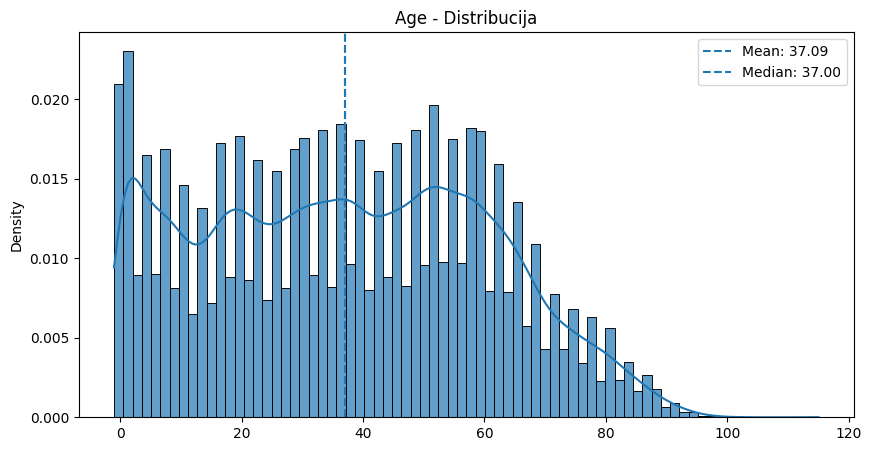

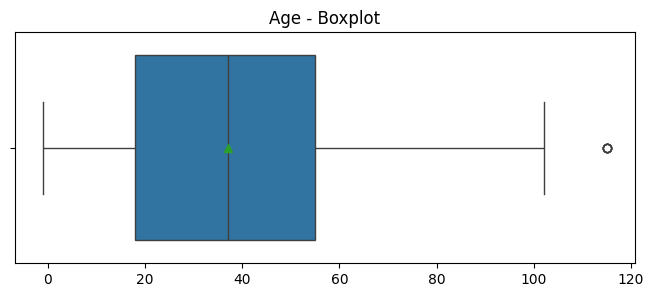

Outliers Report:
Lower fence: -37.50
Upper fence: 110.50
Broj outliera: 5
Procenat: 0.00%

===== AGE ANALIZA =====

Srednja vrednost:
No-show
No     37.790064
Yes    34.317667
Name: Age, dtype: float64

Medijana:
No-show
No     38.0
Yes    33.0
Name: Age, dtype: float64

p-value: 0.000000


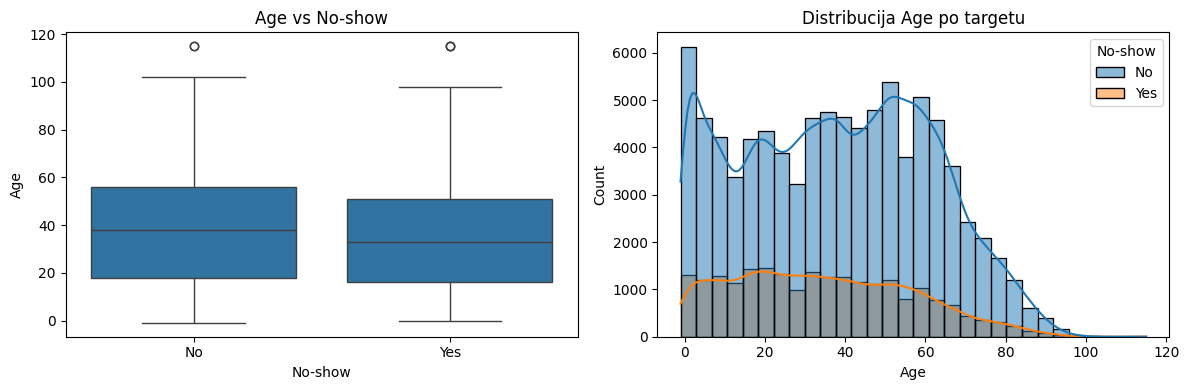

{'Feature': 'Age', 'Razlika_mean': 3.47, 'p_value': 0.0}

In [10]:
plot_age_distribution(df["Age"])
age_outliers_report(df["Age"])
age_result = analyze_age_impact(df)
age_result


### Zakljucak analize atributa *Age* sa aspekta kvaliteta podataka

Atribut Age ne sadrži missing vrednosti, ali su identifikovane pojedine nelogične vrednosti (npr. negativne godine), koje će biti uklonjene u fazi preprocesiranja.

Distribucija atributa pokazuje blagu asimetriju, bez izraženih ekstremnih outliera (manje od 0.01% vrednosti). Granice definisane IQR metodom ukazuju da većina vrednosti pripada realnom opsegu godina.

Analiza uticaja na target varijablu (No-show) pokazuje da postoji statistički značajna razlika između grupa (p < 0.05). Pacijenti koji se nisu pojavili na zakazanom terminu u proseku su mlađi (≈34 godine) u odnosu na one koji su se pojavili (≈38 godina).

Iako je razlika u srednjim vrednostima relativno mala (~3.5 godine), rezultat ukazuje da Age ima određeni prediktivni značaj.

In [11]:
def analyze_binary_feature(df, feature, target="No-show"):
    temp = df.copy()
    temp["target_binary"] = temp[target].map({"No": 0, "Yes": 1})

    counts = temp[feature].value_counts().sort_index()
    percentages = temp[feature].value_counts(normalize=True).sort_index() * 100
    variance = temp[feature].var()

    no_show_rate = temp.groupby(feature)["target_binary"].mean() * 100
    diff = no_show_rate.max() - no_show_rate.min()

    print(f"\n===== Analiza binarnog atributa: {feature} =====")

    print("\n Broj instanci:")
    print(counts)

    print("\n Procenat instanci:")
    print(percentages.round(2).astype(str) + " %")

    print(f"\n Varijansa: {variance:.4f}")

    imbalance_ratio = counts.min() / counts.max()
    print(f"\n Odnos manjinske/većinske klase: {imbalance_ratio:.2f}")

    print("\n No-show stopa po grupama:")
    print(no_show_rate.round(2).astype(str) + " %")

    print(f"\n Razlika u No-show stopi između grupa: {diff:.2f} p.p.")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(x=counts.index, y=counts.values, ax=axes[0])
    axes[0].set_title(f"Raspodela vrednosti atributa {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Broj instanci")

    sns.barplot(x=no_show_rate.index, y=no_show_rate.values, ax=axes[1])
    axes[1].set_title(f"No-show stopa po grupama za {feature}")
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel("No-show stopa (%)")

    plt.tight_layout()
    plt.show()

    return {
        "Feature": feature,
        "Tip": "binarni",
        "Varijansa": round(float(variance), 4),
        "Razlika_u_NoShow_%": round(float(diff), 2)
    }


===== Analiza binarnog atributa: Scholarship =====

 Broj instanci:
Scholarship
0    99666
1    10861
Name: count, dtype: int64

 Procenat instanci:
Scholarship
0    90.17 %
1     9.83 %
Name: proportion, dtype: object

 Varijansa: 0.0886

 Odnos manjinske/većinske klase: 0.11

 No-show stopa po grupama:
Scholarship
0    19.81 %
1    23.74 %
Name: target_binary, dtype: object

 Razlika u No-show stopi između grupa: 3.93 p.p.


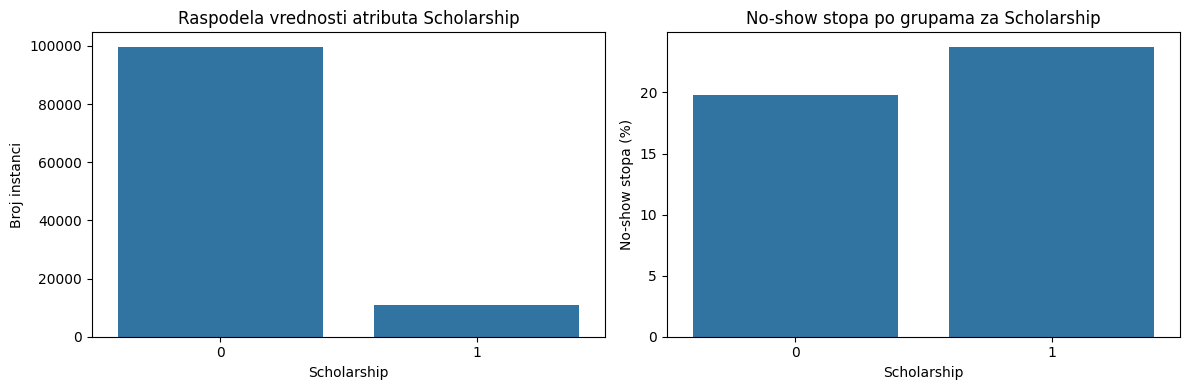


===== Analiza binarnog atributa: Hipertension =====

 Broj instanci:
Hipertension
0    88726
1    21801
Name: count, dtype: int64

 Procenat instanci:
Hipertension
0    80.28 %
1    19.72 %
Name: proportion, dtype: object

 Varijansa: 0.1583

 Odnos manjinske/većinske klase: 0.25

 No-show stopa po grupama:
Hipertension
0    20.9 %
1    17.3 %
Name: target_binary, dtype: object

 Razlika u No-show stopi između grupa: 3.60 p.p.


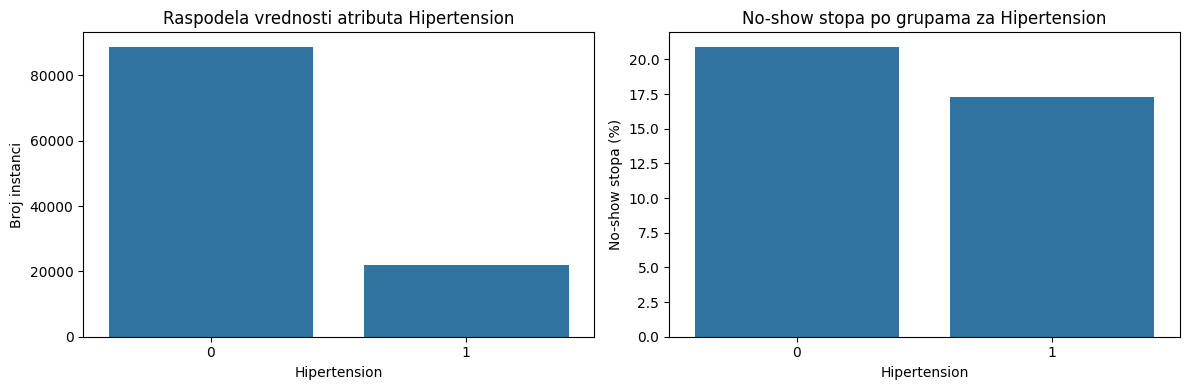


===== Analiza binarnog atributa: Diabetes =====

 Broj instanci:
Diabetes
0    102584
1      7943
Name: count, dtype: int64

 Procenat instanci:
Diabetes
0    92.81 %
1     7.19 %
Name: proportion, dtype: object

 Varijansa: 0.0667

 Odnos manjinske/većinske klase: 0.08

 No-show stopa po grupama:
Diabetes
0    20.36 %
1     18.0 %
Name: target_binary, dtype: object

 Razlika u No-show stopi između grupa: 2.36 p.p.


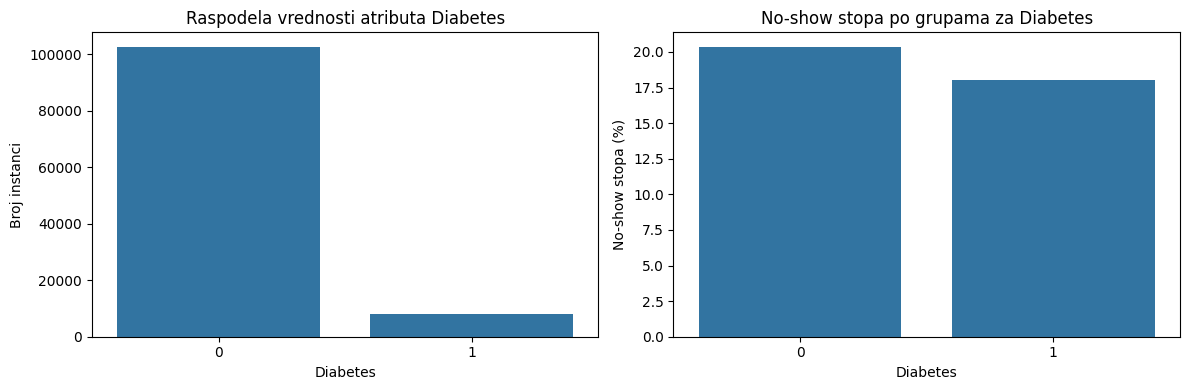


===== Analiza binarnog atributa: Alcoholism =====

 Broj instanci:
Alcoholism
0    107167
1      3360
Name: count, dtype: int64

 Procenat instanci:
Alcoholism
0    96.96 %
1     3.04 %
Name: proportion, dtype: object

 Varijansa: 0.0295

 Odnos manjinske/većinske klase: 0.03

 No-show stopa po grupama:
Alcoholism
0    20.19 %
1    20.15 %
Name: target_binary, dtype: object

 Razlika u No-show stopi između grupa: 0.05 p.p.


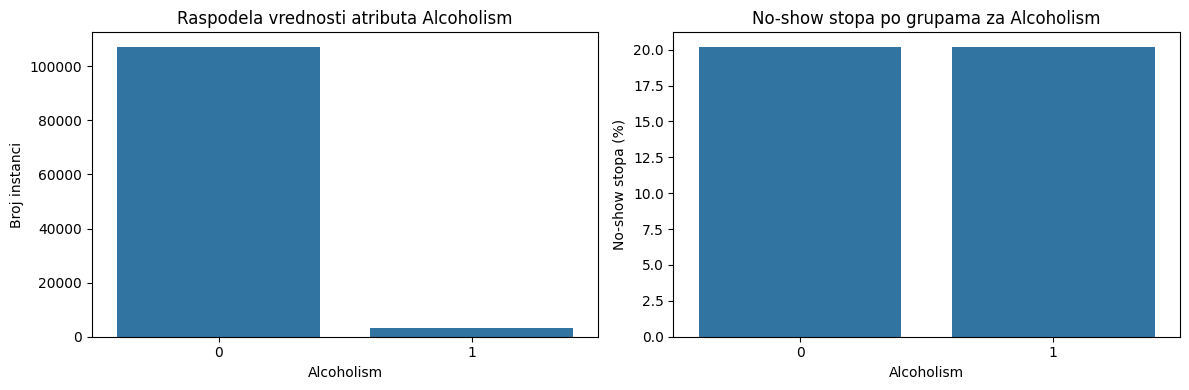


===== Analiza binarnog atributa: SMS_received =====

 Broj instanci:
SMS_received
0    75045
1    35482
Name: count, dtype: int64

 Procenat instanci:
SMS_received
0    67.9 %
1    32.1 %
Name: proportion, dtype: object

 Varijansa: 0.2180

 Odnos manjinske/većinske klase: 0.47

 No-show stopa po grupama:
SMS_received
0     16.7 %
1    27.57 %
Name: target_binary, dtype: object

 Razlika u No-show stopi između grupa: 10.87 p.p.


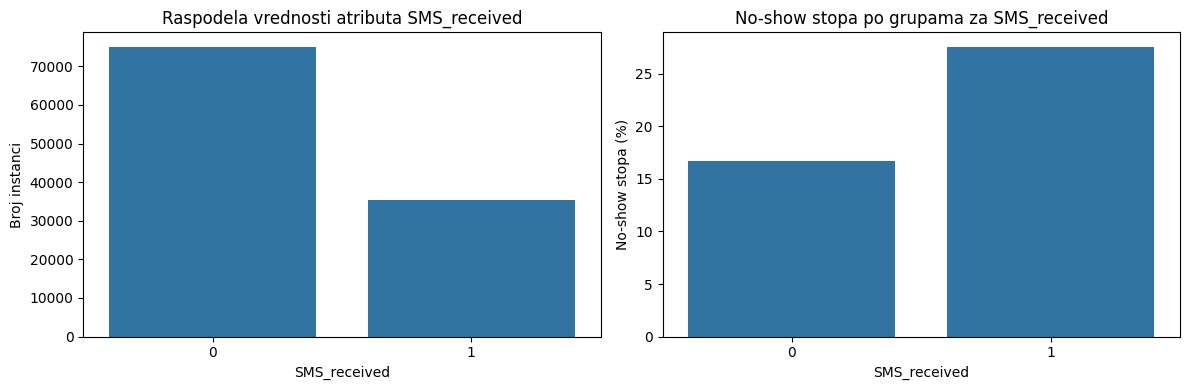

In [12]:
binary_results = []

binary_results.append(analyze_binary_feature(df, "Scholarship"))
binary_results.append(analyze_binary_feature(df, "Hipertension"))
binary_results.append(analyze_binary_feature(df, "Diabetes"))
binary_results.append(analyze_binary_feature(df, "Alcoholism"))
binary_results.append(analyze_binary_feature(df, "SMS_received"))

### Analiza binarnih atributa

###  Scholarship

Atribut **Scholarship** je izrazito neuravnotežen (≈90% pacijenata nema stipendiju). Primećuje se da pacijenti koji imaju stipendiju imaju veću *No-show* stopu (≈23.7%) u odnosu na ostale (≈19.8%). Razlika iznosi oko **3.9 procentnih poena**, što ukazuje na umeren uticaj ovog atributa.

**Dalji koraci:**
- Atribut zadržati u modelu
- Rezultate interpretirati pažljivo zbog neuravnoteženosti
- Mogući indikator socio-ekonomskih faktora

---

###  Hipertension

Atribut **Hipertension** pokazuje da pacijenti bez hipertenzije imaju veću *No-show* stopu (≈20.9%) u odnosu na pacijente sa hipertenzijom (≈17.3%). Razlika iznosi oko **3.6 p.p.**

Ovaj rezultat ukazuje da pacijenti sa hroničnim bolestima imaju veću verovatnoću da se pojave na pregledu.

**Dalji koraci:**
- Atribut zadržati u modelu
- Predstavlja koristan signal ponašanja pacijenata

---

###  Diabetes

Atribut **Diabetes** je neuravnotežen (≈93% pacijenata nema dijabetes). Pacijenti bez dijabetesa imaju nešto veću *No-show* stopu (≈20.4%) u odnosu na pacijente sa dijabetesom (≈18.0%). Razlika je oko **2.4 p.p.**, što ukazuje na slab uticaj.

**Dalji koraci:**
- Atribut zadržati u modelu
- Ima slab individualni uticaj, ali može doprineti u kombinaciji sa drugim atributima

---

###  Alcoholism

Atribut **Alcoholism** je ekstremno neuravnotežen (≈97% pacijenata nema ovu karakteristiku). *No-show* stopa je gotovo identična u obe grupe (~20%), sa zanemarljivom razlikom (**≈0.05 p.p.**).

Ovaj atribut ne pokazuje prediktivni značaj.

**Dalji koraci:**
- Razmotriti izbacivanje iz modela
- Ne doprinosi performansama

---

###  SMS_received

Atribut **SMS_received** pokazuje najveću razliku među analiziranim atributima. Pacijenti koji su primili SMS imaju značajno veću *No-show* stopu (≈27.6%) u odnosu na one koji nisu (≈16.7%). Razlika iznosi čak **≈10.9 p.p.**

Na prvi pogled, ovaj rezultat deluje kontradiktorno i ukazuje na postojanje skrivenih faktora (npr. dužina čekanja).

**Dalji koraci:**
- Atribut obavezno zadržati
- Neophodna dodatna analiza u kombinaciji sa atributom *WaitingDays*

---

### Opšti zaključak

Analiza binarnih atributa pokazuje da većina atributa ima slab do umeren individualni uticaj na target varijablu. Najizraženiji efekat ima atribut **SMS_received**, dok atribut **Alcoholism** ne pokazuje značajan uticaj.

Takođe, primećeno je da atributi koji predstavljaju hronična stanja (*Hipertension*, *Diabetes*) imaju obrnut efekat, što ukazuje da pacijenti sa ozbiljnijim zdravstvenim problemima imaju veću verovatnoću da se pojave na zakazanom pregledu.

Neuravnoteženost atributa predstavlja važan faktor koji treba uzeti u obzir prilikom interpretacije rezultata i izgradnje modela.

---


===== Analiza diskretnog atributa: Handcap =====

 Broj instanci:
Handcap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

 Procenat instanci:
Handcap
0    97.97 %
1     1.85 %
2     0.17 %
3     0.01 %
4      0.0 %
Name: proportion, dtype: object

 Varijansa: 0.0261

 No-show stopa po vrednostima:
Handcap
0    20.24 %
1    17.92 %
2    20.22 %
3    23.08 %
4    33.33 %
Name: target_binary, dtype: object

 Maksimalna razlika u No-show stopi: 15.41 p.p.


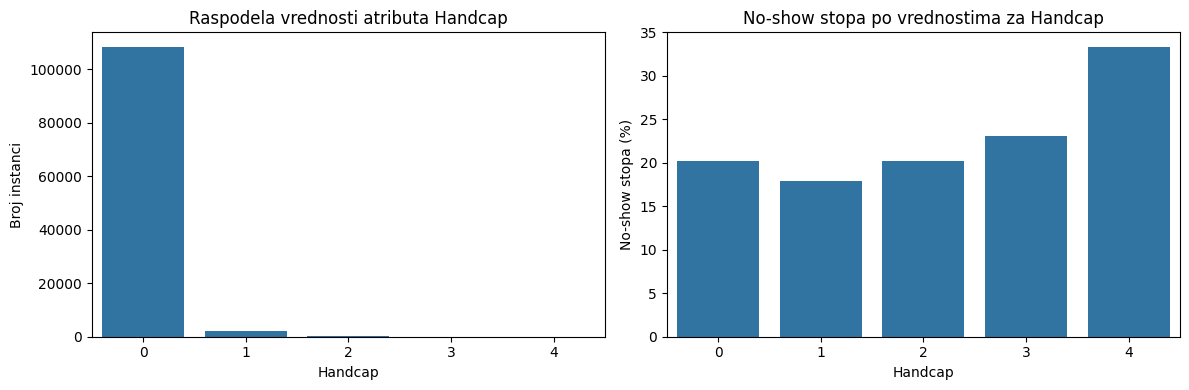

In [13]:
def analyze_discrete_feature(df, feature, target="No-show"):
    temp = df.copy()
    temp["target_binary"] = temp[target].map({"No": 0, "Yes": 1})

    counts = temp[feature].value_counts().sort_index()
    percentages = temp[feature].value_counts(normalize=True).sort_index() * 100
    variance = temp[feature].var()

    no_show_rate = temp.groupby(feature)["target_binary"].mean() * 100
    diff = no_show_rate.max() - no_show_rate.min()

    print(f"\n===== Analiza diskretnog atributa: {feature} =====")
    print("\n Broj instanci:")
    print(counts)

    print("\n Procenat instanci:")
    print(percentages.round(2).astype(str) + " %")

    print(f"\n Varijansa: {variance:.4f}")

    print("\n No-show stopa po vrednostima:")
    print(no_show_rate.round(2).astype(str) + " %")

    print(f"\n Maksimalna razlika u No-show stopi: {diff:.2f} p.p.")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(x=counts.index, y=counts.values, ax=axes[0])
    axes[0].set_title(f"Raspodela vrednosti atributa {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Broj instanci")

    sns.barplot(x=no_show_rate.index, y=no_show_rate.values, ax=axes[1])
    axes[1].set_title(f"No-show stopa po vrednostima za {feature}")
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel("No-show stopa (%)")

    plt.tight_layout()
    plt.show()

    return {
        "Feature": feature,
        "Tip": "diskretni",
        "Varijansa": round(float(variance), 4),
        "Razlika_u_NoShow_%": round(float(diff), 2)
    }

handcap_result = analyze_discrete_feature(df, "Handcap")

###  Handcap

Atribut **Handcap** predstavlja diskretni atribut sa više vrednosti (0–4), gde većina pacijenata nema hendikep (≈98%). Ostale vrednosti su izuzetno retke i čine vrlo mali procenat skupa podataka.

Analiza pokazuje da se *No-show* stopa povećava sa većim vrednostima atributa, pri čemu najviša vrednost (4) ima najveću stopu (≈33%). Međutim, ove grupe sadrže veoma mali broj instanci, zbog čega rezultati nisu statistički pouzdani.

Ovakva raspodela ukazuje na ozbiljan problem neuravnoteženosti i nedovoljnog broja podataka za više kategorije.


---

### Napomena

Iako na prvi pogled deluje da veći stepen hendikepa povećava verovatnoću *No-show*, ovaj zaključak nije pouzdan zbog ekstremno malog broja primera u tim grupama. Zbog toga je neophodno pojednostaviti atribut pre korišćenja u modelu.

## 2.3 Analiza kategorijskih feature-a

In [14]:
# Izdvajanje kategorijskih atributa
categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()

print("Kategorijski atributi u datasetu:\n")

for i, col in enumerate(categorical_features, 1):
    unique_vals = df[col].nunique()
    print(f"{i}. {col} (broj kategorija: {unique_vals})")

print(f"\nUkupan broj kategorijskih atributa: {len(categorical_features)}")

Kategorijski atributi u datasetu:

1. Gender (broj kategorija: 2)
2. ScheduledDay (broj kategorija: 103549)
3. AppointmentDay (broj kategorija: 27)
4. Neighbourhood (broj kategorija: 81)
5. No-show (broj kategorija: 2)

Ukupan broj kategorijskih atributa: 5


In [15]:
categorical_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Broj_kategorija": [df[col].nunique() for col in categorical_features],
    "Missing": [df[col].isna().sum() for col in categorical_features]
})

display(categorical_summary.sort_values(by="Broj_kategorija", ascending=False))

,Feature,Broj_kategorija,Missing
1,ScheduledDay,103549,0
3,Neighbourhood,81,0
2,AppointmentDay,27,0
0,Gender,2,0
4,No-show,2,0


In [16]:
def analyze_categorical_feature(df, feature, target="No-show"):
    temp = df.copy()
    temp["target_binary"] = temp[target].map({"No": 0, "Yes": 1})

    counts = temp[feature].value_counts()
    percentages = temp[feature].value_counts(normalize=True) * 100
    unique_vals = temp[feature].nunique()

    no_show_rate = temp.groupby(feature)["target_binary"].mean() * 100

    print(f"\n===== Analiza kategorijskog atributa: {feature} =====")

    print(f"\n Broj kategorija: {unique_vals}")

    print("\n Najčešće vrednosti:")
    display(counts.head())

    print("\n Procenat (top kategorije):")
    display(percentages.head().round(2))

    print("\n No-show stopa po kategorijama (top):")
    display(no_show_rate.sort_values(ascending=False).head().round(2))

    # Vizualizacija
    plt.figure(figsize=(10,4))
    counts.head(10).plot(kind='bar')
    plt.title(f"Top 10 kategorija za {feature}")
    plt.show()

    return {
        "Feature": feature,
        "Broj_kategorija": unique_vals,
        "Max_NoShow": round(no_show_rate.max(), 2),
        "Min_NoShow": round(no_show_rate.min(), 2)
    }


===== Analiza kategorijskog atributa: Gender =====

 Broj kategorija: 2

 Najčešće vrednosti:


Gender
F    71840
M    38687
Name: count, dtype: int64


 Procenat (top kategorije):


Gender
F    65.0
M    35.0
Name: proportion, dtype: float64


 No-show stopa po kategorijama (top):


Gender
F    20.31
M    19.97
Name: target_binary, dtype: float64

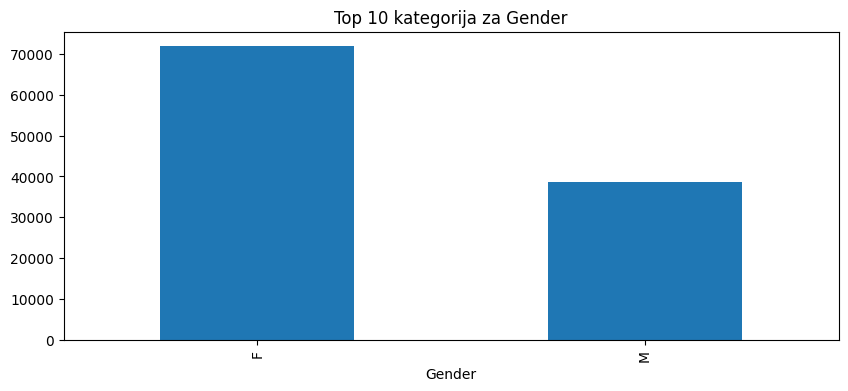


===== Analiza kategorijskog atributa: Neighbourhood =====

 Broj kategorija: 81

 Najčešće vrednosti:


Neighbourhood
JARDIM CAMBURI     7717
MARIA ORTIZ        5805
RESISTÊNCIA        4431
JARDIM DA PENHA    3877
ITARARÉ            3514
Name: count, dtype: int64


 Procenat (top kategorije):


Neighbourhood
JARDIM CAMBURI     6.98
MARIA ORTIZ        5.25
RESISTÊNCIA        4.01
JARDIM DA PENHA    3.51
ITARARÉ            3.18
Name: proportion, dtype: float64


 No-show stopa po kategorijama (top):


Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    100.00
SANTOS DUMONT                   28.92
SANTA CECÍLIA                   27.46
SANTA CLARA                     26.48
ITARARÉ                         26.27
Name: target_binary, dtype: float64

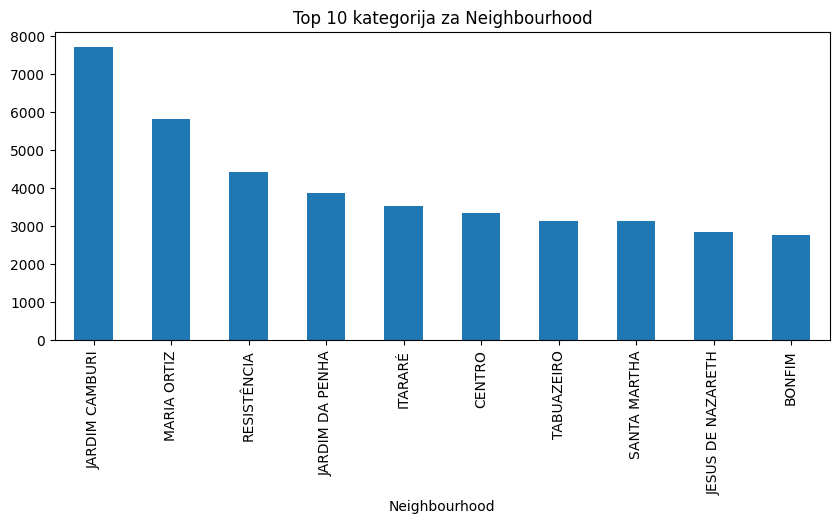

In [17]:
cat_results = []

cat_results.append(analyze_categorical_feature(df, "Gender"))
cat_results.append(analyze_categorical_feature(df, "Neighbourhood"))

In [18]:
neighbourhood_rates = (
    df.assign(target_binary=df["No-show"].map({"No": 0, "Yes": 1}))
    .groupby("Neighbourhood")["target_binary"]
    .mean() * 100
).sort_values(ascending=False)

display(neighbourhood_rates.head(10))
display(neighbourhood_rates.tail(10))

Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    100.000000
SANTOS DUMONT                   28.918495
SANTA CECÍLIA                   27.455357
SANTA CLARA                     26.482213
ITARARÉ                         26.266363
JESUS DE NAZARETH               24.395373
HORTO                           24.000000
ILHA DO PRÍNCIPE                23.477493
CARATOÍRA                       23.040936
ANDORINHAS                      23.032714
Name: target_binary, dtype: float64

Neighbourhood
DO QUADRO            16.489988
JARDIM DA PENHA      16.275471
SANTA MARTHA         15.841584
DO CABRAL            15.714286
DE LOURDES           15.409836
SOLON BORGES         14.712154
MÁRIO CYPRESTE       14.555256
AEROPORTO            12.500000
ILHA DO BOI           8.571429
PARQUE INDUSTRIAL     0.000000
Name: target_binary, dtype: float64

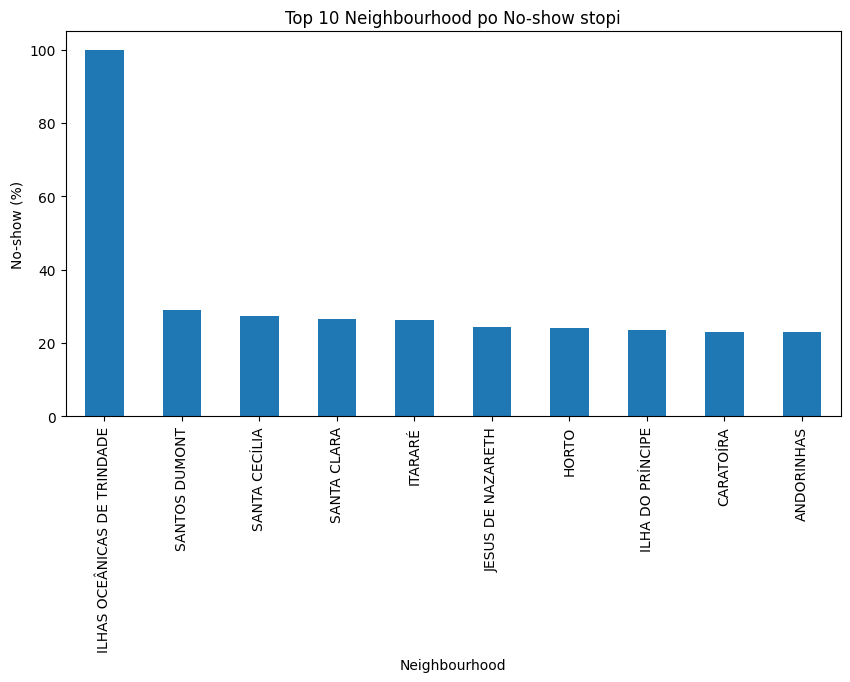

In [64]:
plt.figure(figsize=(10,5))
neighbourhood_rates.head(10).plot(kind='bar')
plt.title("Top 10 Neighbourhood po No-show stopi")
plt.ylabel("No-show (%)")
plt.show()

Kategorijski atributi u datasetu imaju različite nivoe kardinalnosti. Atribut Gender ima nisku kardinalnost i pogodan je za direktno enkodovanje, dok atribut Neighbourhood ima visoku kardinalnost, što može predstavljati izazov zbog povećanja dimenzionalnosti modela.

Datumski atributi (ScheduledDay i AppointmentDay) zahtevaju transformaciju u numeričke ili vremenske feature-e i ne koriste se direktno kao kategorijski atributi.

Na osnovu analize, atributi će biti tretirani na sledeći način:
- Gender → one-hot encoding
- Neighbourhood → one-hot encoding (napomena o visokoj kardinalnosti)
- ScheduledDay, AppointmentDay → feature engineering

###  Neighbourhood

Atribut **Neighbourhood** ima visoku kardinalnost (81 različita vrednost), što predstavlja izazov u analizi i modelovanju.

Analiza pokazuje da postoje značajne razlike u *No-show* stopi između različitih lokacija, što ukazuje da ovaj atribut nosi informaciju relevantnu za predikciju.

Međutim, zbog velikog broja kategorija:
- nije praktično analizirati svaku kategoriju pojedinačno
- postoji rizik od povećanja dimenzionalnosti prilikom enkodovanja

**Dalji koraci:**
- Atribut zadržati zbog informativnosti
- Primeniti one-hot encoding
- Uočiti potencijalne probleme sa visokom kardinalnošću

---

### Napomena

Razlike u *No-show* stopi između različitih lokacija mogu ukazivati na socio-ekonomske ili geografske faktore koji utiču na ponašanje pacijenata.

## 2.4 No-show : tagret varijabla

In [20]:
df["No-show"].value_counts(normalize=True) * 100

No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

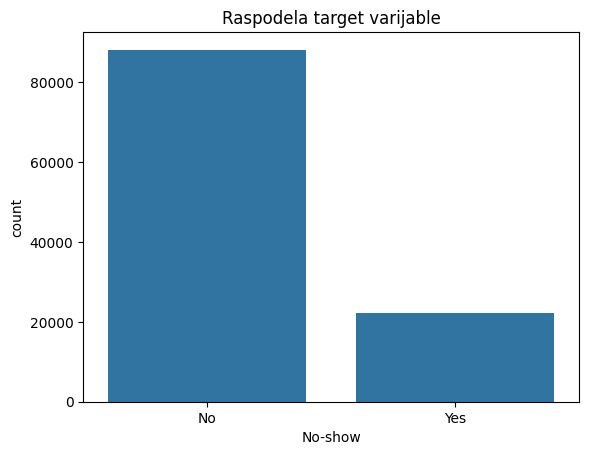

In [21]:
sns.countplot(data=df, x="No-show")
plt.title("Raspodela target varijable")
plt.show()

### Analiza target varijable

Target varijabla **No-show** predstavlja da li se pacijent pojavio na zakazanom terminu.

Analiza raspodele pokazuje da su klase neuravnotežene, pri čemu većinu čine pacijenti koji su se pojavili na pregledu.

Ovakva neuravnoteženost može uticati na performanse modela, zbog čega će se u daljoj analizi posebna pažnja posvetiti metrikama kao što su precision, recall i F1-score, umesto oslanjanja isključivo na accuracy.

## 2.5 Analiza vremenskih atributa

(ScheduledDay i AppointmentDay)

Napomena: Iako su ovi atributi inicijalno tipa string, njihova semantička priroda ukazuje da se radi o vremenskim (datetime) atributima, te se analiziraju kao posebna kategorija.

datetime64[ns, UTC]
datetime64[ns, UTC]
ScheduledDay missing: 0
AppointmentDay missing: 0
Negativni WaitingDays: 5


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays
27033,7.839273e+12,5679978,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,-1
55226,7.896294e+12,5715660,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,-1
64175,2.425226e+13,5664962,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,-1
71533,9.982316e+14,5686628,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,-6
72362,3.787482e+12,5655637,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,-1


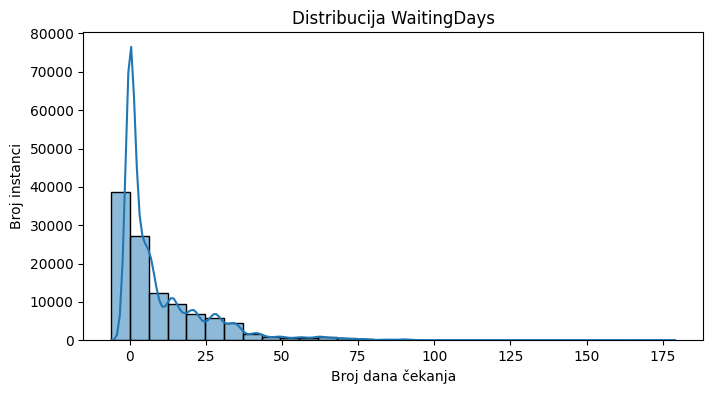

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64

In [22]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# Provera tipova
print(df["ScheduledDay"].dtype)
print(df["AppointmentDay"].dtype)


print("ScheduledDay missing:", df["ScheduledDay"].isna().sum())
print("AppointmentDay missing:", df["AppointmentDay"].isna().sum())


df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize() -
    df["ScheduledDay"].dt.normalize()
).dt.days


negative_waiting = (df["WaitingDays"] < 0).sum()
print("Negativni WaitingDays:", negative_waiting)

# Prikaz problematičnih redova
display(df[df["WaitingDays"] < 0].head())


plt.figure(figsize=(8,4))
sns.histplot(df["WaitingDays"], bins=30, kde=True)
plt.title("Distribucija WaitingDays")
plt.xlabel("Broj dana čekanja")
plt.ylabel("Broj instanci")
plt.show()


display(df["WaitingDays"].describe())



###  Analiza vremenskih atributa

Atributi **ScheduledDay** i **AppointmentDay** inicijalno su učitani kao string vrednosti, ali po svojoj prirodi predstavljaju vremenske podatke.

- **ScheduledDay** označava trenutak zakazivanja pregleda  
- **AppointmentDay** označava datum održavanja pregleda  

---

###  Konverzija tipa podataka

Oba atributa su uspešno konvertovana u `datetime` format bez grešaka.  
Takođe, nije detektovano prisustvo nedostajućih vrednosti, što ukazuje na visok kvalitet podataka.

---

###  Provera logičke konzistentnosti

Analizom je utvrđeno da postoji mali broj slučajeva gde je:

- `AppointmentDay < ScheduledDay`

Ove situacije dovode do negativnih vrednosti atributa *WaitingDays* i predstavljaju greške u podacima.

---

### Atribut WaitingDays (vreme čekanja)

Atribut **WaitingDays** definisan je kao razlika između datuma pregleda i datuma zakazivanja (u danima).

Ovaj atribut predstavlja ključnu izvedenu promenljivu jer direktno opisuje koliko dugo pacijent čeka na pregled.

---

###  Distribucija

Distribucija atributa *WaitingDays* je izrazito desno asimetrična:

- najveći broj pacijenata čeka kratak vremenski period (0–10 dana)
- manji broj pacijenata ima značajno duže čekanje (do ~180 dana)

---

###  Problemi kvaliteta podataka

Identifikovane su negativne vrednosti koje predstavljaju nelogične zapise.  
Ove vrednosti će biti uklonjene iz dataset-a kako bi se obezbedila konzistentnost podataka. (u improved modelu)

---

###  Dalja obrada

Na osnovu analize, atribut *WaitingDays* će biti tretiran na sledeći način:

-  uklanjanje nelogičnih vrednosti (`WaitingDays < 0`)
-  zadržavanje atributa u modelu
-  potencijalno grupisanje (binning) radi bolje interpretacije

---

###  Zaključak

Atribut **WaitingDays** predstavlja jednu od najvažnijih promenljivih u datasetu.

Direktno opisuje ponašanje pacijenata i omogućava analizu uticaja vremena čekanja na pojavu *No-show*.  
Nakon uklanjanja nekonzistentnih vrednosti, atribut ima visok potencijal za unapređenje modela.

## 2.5 Feature engineering

Na osnovu prethodne analize podataka, kreirani su novi atributi sa ciljem boljeg hvatanja obrazaca u ponašanju pacijenata.

Kreirani atributi su zasnovani na postojećim podacima i imaju jasnu interpretaciju, što doprinosi kvalitetu modela i objašnjivosti rezultata.

In [23]:
df["AppointmentDayOfWeek"] = df["AppointmentDay"].dt.day_name()

In [24]:
def categorize_waiting(days):
    if days == 0:
        return "0"
    elif days <= 3:
        return "1-3"
    elif days <= 7:
        return "4-7"
    elif days <= 14:
        return "8-14"
    else:
        return "15+"

df["WaitingDaysGroup"] = df["WaitingDays"].apply(categorize_waiting)

In [25]:
def age_group(age):
    if age < 18:
        return "Child"
    elif age < 40:
        return "Young"
    elif age < 65:
        return "Adult"
    else:
        return "Senior"

df["AgeGroup"] = df["Age"].apply(age_group)

###  Kreirani atributi

- **AppointmentDayOfWeek** – dan u nedelji zakazanog pregleda  
- **WaitingDaysGroup** – grupisano vreme čekanja  
- **AgeGroup** – starosna kategorija pacijenta  

Ovi atributi omogućavaju lakšu interpretaciju i potencijalno bolje performanse modela.

### WaitingDaysGroup vs No-show

WaitingDaysGroup
0        4.646941
1-3     22.915531
15+     32.743522
4-7     25.202741
8-14    30.469854
Name: target_binary, dtype: float64

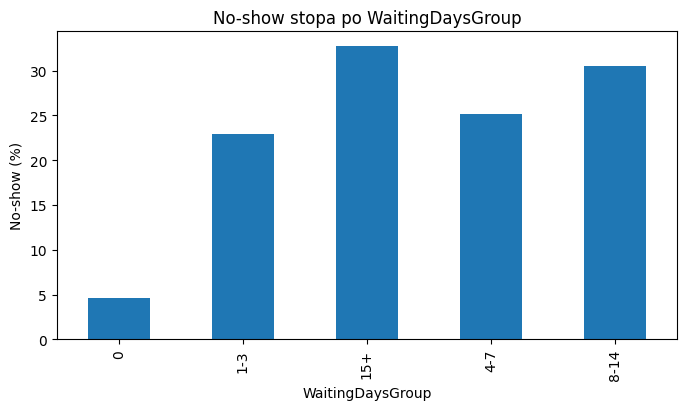

In [26]:
waiting_analysis = (
    df.assign(target_binary=df["No-show"].map({"No": 0, "Yes": 1}))
    .groupby("WaitingDaysGroup")["target_binary"]
    .mean() * 100
)

display(waiting_analysis)

plt.figure(figsize=(8,4))
waiting_analysis.plot(kind='bar')
plt.title("No-show stopa po WaitingDaysGroup")
plt.ylabel("No-show (%)")
plt.xlabel("WaitingDaysGroup")
plt.show()

###  WaitingDaysGroup i No-show

Analiza pokazuje jasan trend između vremena čekanja i pojave *No-show*.

Pacijenti koji čekaju kraći vremenski period imaju manju verovatnoću da propuste termin, dok se sa povećanjem vremena čekanja značajno povećava i *No-show* stopa.

Ovaj rezultat je intuitivan i potvrđuje da duže čekanje negativno utiče na dolazak pacijenata.

### SMS + WaitingDays

SMS_received,0,1
WaitingDaysGroup,,
0,4.646941,NaN
1-3,23.021635,21.302428
15+,37.110639,29.952747
4-7,27.111241,23.971058
8-14,33.758215,28.112507


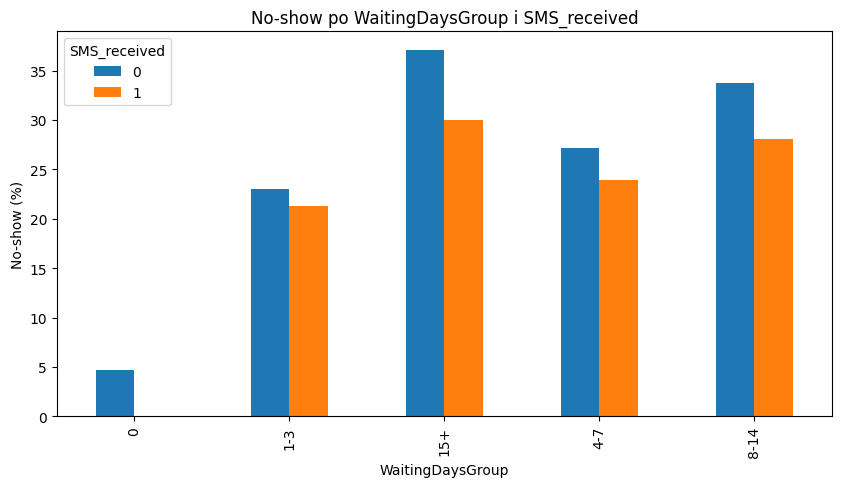

In [27]:
sms_waiting = (
    df.assign(target_binary=df["No-show"].map({"No": 0, "Yes": 1}))
    .groupby(["WaitingDaysGroup", "SMS_received"])["target_binary"]
    .mean() * 100
).unstack()

display(sms_waiting)

sms_waiting.plot(kind="bar", figsize=(10,5))
plt.title("No-show po WaitingDaysGroup i SMS_received")
plt.ylabel("No-show (%)")
plt.show()

###  SMS_received i WaitingDays (zajednička analiza)

Na prvi pogled, atribut *SMS_received* sugeriše da pacijenti koji su primili SMS imaju veću *No-show* stopu.

Međutim, analizom u kombinaciji sa atributom *WaitingDaysGroup* uočava se da:

- pacijenti koji duže čekaju imaju veću verovatnoću da prime SMS
- duže čekanje samo po sebi povećava *No-show* stopu

To znači da atribut *SMS_received* nije uzrok povećanog *No-show*, već je povezan sa drugim faktorom – vremenom čekanja.

Ovaj fenomen predstavlja primer **confounding efekta**, gde treća promenljiva utiče na odnos između posmatranih atributa.

---

### Zaključak

Vreme čekanja (*WaitingDays*) je ključni faktor koji utiče na pojavu *No-show*, dok je efekat SMS podsetnika sekundaran i uslovljen dužinom čekanja.

## 2.6 Analiza zavisnosti medju atributima

### 2.6.1 Korelacija numeričkih atributa

Cilj je da vidimo medjusobne veze izmedju numerickih atributa i proverimo multikolinearnost

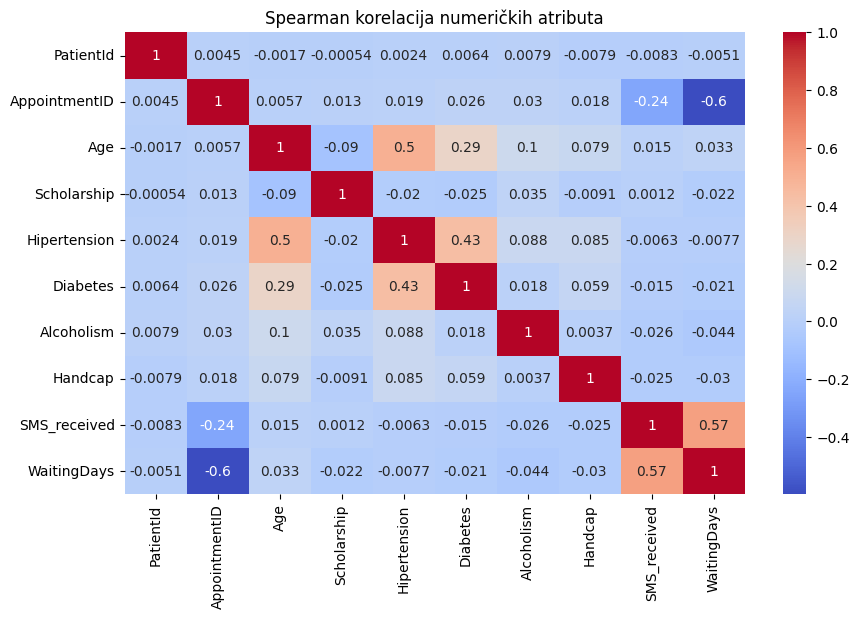

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm')
plt.title("Spearman korelacija numeričkih atributa")
plt.show()

Za analizu međusobne povezanosti numeričkih atributa korišćena je Spearman korelacija, koja je pogodna za detekciju monotonih veza i robusnija je na outliere i nenormalne raspodele podataka.

Rezultati pokazuju da između većine numeričkih atributa ne postoji jaka korelacija, ali su uočene određene umerene veze. Posebno se izdvaja korelacija između atributa WaitingDays i SMS_received, što ukazuje da pacijenti koji duže čekaju češće dobijaju SMS podsetnike.

Takođe, primećena je umerena povezanost između Age i Hipertension, što je očekivano sa medicinskog aspekta.

Ipak, nijedna korelacija nije dovoljno visoka da bi ukazivala na izraženu multikolinearnost, što je povoljno za dalje modelovanje.

### 2.6.2 Povezanost numeričkih atributa sa targetom



In [29]:
import pandas as pd

df_numeric = df.copy()
df_numeric["NoShow_binary"] = df_numeric["No-show"].map({"Yes": 1, "No": 0})

corr_with_target = df_numeric[numeric_cols].corrwith(df_numeric["NoShow_binary"], method="spearman")

corr_with_target = corr_with_target.sort_values(ascending=False)

display(corr_with_target.to_frame(name="Spearman korelacija sa targetom"))

,Spearman korelacija sa targetom
WaitingDays,0.281648
SMS_received,0.126431
Scholarship,0.029135
Alcoholism,-0.000196
PatientId,-0.000711
Handcap,-0.007265
Diabetes,-0.015180
Hipertension,-0.035701
Age,-0.061228
AppointmentID,-0.171739


Analiza korelacije između numeričkih atributa i target varijable pokazuje da nijedan pojedinačni atribut nema jaku povezanost sa No-show ishodom.

Najveći uticaj ima atribut WaitingDays, koji pokazuje umerenu pozitivnu korelaciju, što znači da duže čekanje povećava verovatnoću nedolaska pacijenata.

Atribut SMS_received pokazuje slabu korelaciju, što sugeriše da njegov efekat nije direktan, već zavisi od drugih faktora.

Ovi rezultati ukazuju da pojedinačni atributi imaju ograničenu prediktivnu moć i da je za bolje razumevanje ponašanja target varijable neophodno analizirati njihove međusobne interakcije.

### 2.6.3 Povezanost kategorijskih atributa sa targetom (Cramér’s V)

In [30]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    if min(r, k) <= 1:
        return np.nan
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

categorical_cols = df.select_dtypes(include=['object']).columns.drop("No-show")

cramers_results = []

for col in categorical_cols:
    v = cramers_v(df[col], df["No-show"])
    cramers_results.append((col, v))

cramers_df = pd.DataFrame(cramers_results, columns=["Feature", "Cramers_V"])
cramers_df = cramers_df.sort_values(by="Cramers_V", ascending=False)

display(cramers_df)

,Feature,Cramers_V
3,WaitingDaysGroup,0.295077
4,AgeGroup,0.069557
1,Neighbourhood,0.066714
2,AppointmentDayOfWeek,0.015765
0,Gender,0.004095


Cramér’s V metrika korišćena je za procenu povezanosti kategorijskih atributa sa target varijablom.

Rezultati pokazuju da većina atributa ima slabu povezanost sa No-show ishodom. Najveći uticaj ima atribut WaitingDaysGroup, što potvrđuje prethodne nalaze da duže čekanje značajno utiče na verovatnoću nedolaska.

Ostali atributi, uključujući Neighbourhood, AgeGroup i AppointmentDayOfWeek, pokazuju znatno slabiju povezanost.

Ovo dodatno potvrđuje da ponašanje target varijable nije determinisano jednim atributom, već zavisi od kombinacije više faktora.

### 2.6.4 Interakcije atributa 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4724\355672470.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["WaitingDays_group", "SMS_received"])["No-show"].apply(


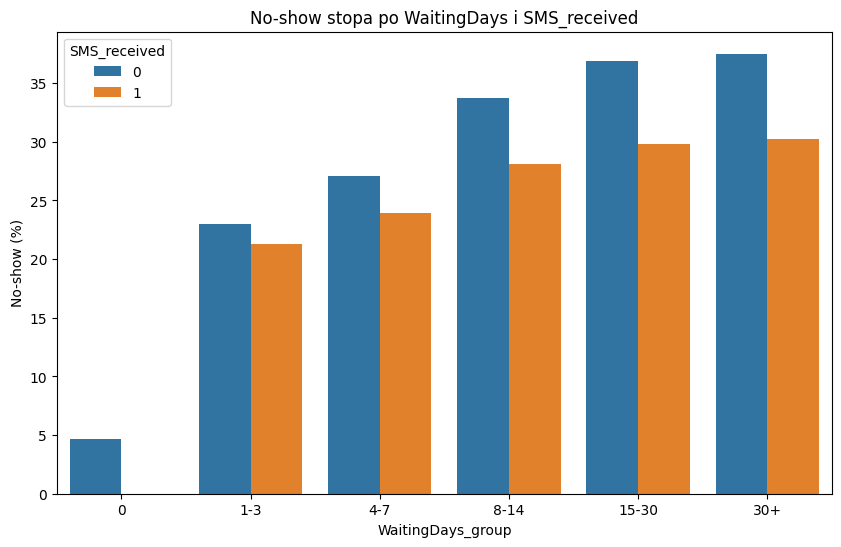

In [31]:
df["WaitingDays_group"] = pd.cut(
    df["WaitingDays"],
    bins=[-1, 0, 3, 7, 14, 30, 1000],
    labels=["0", "1-3", "4-7", "8-14", "15-30", "30+"]
)

grouped = df.groupby(["WaitingDays_group", "SMS_received"])["No-show"].apply(
    lambda x: (x == "Yes").mean() * 100
).reset_index(name="No-show rate")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=grouped, x="WaitingDays_group", y="No-show rate", hue="SMS_received")
plt.title("No-show stopa po WaitingDays i SMS_received")
plt.ylabel("No-show (%)")
plt.show()

Na prvi pogled, analiza može sugerisati da pacijenti koji su primili SMS podsetnik imaju veću stopu nedolaska, što bi moglo dovesti do pogrešnog zaključka da SMS podsetnici imaju negativan efekat.

Međutim, dodatna analiza pokazuje da pacijenti sa dužim WaitingDays periodom češće dobijaju SMS podsetnike, kao i da su oni ujedno skloniji nedolasku.

Stratifikacijom po WaitingDays postaje jasno da SMS podsetnici zapravo smanjuju stopu nedolaska unutar svake grupe čekanja, ali da ukupna slika može biti iskrivljena zbog uticaja WaitingDays kao skrivenog faktora.

Ovaj primer jasno ilustruje značaj analize interakcija atributa i identifikacije konfuznih faktora (confounders) u procesu analize podataka.

### Zakljucak 2.6 sekcije 

Analiza zavisnosti među atributima pokazuje da pojedinačni atributi imaju ograničenu povezanost sa target varijablom i da ne postoji izražena multikolinearnost među numeričkim atributima.

Najznačajniji uvid dolazi iz analize interakcija, gde se pokazuje da kombinacija atributa, poput WaitingDays i SMS_received, ima ključnu ulogu u objašnjenju ponašanja pacijenata.

Ovi rezultati ukazuju da je za uspešno modelovanje neophodno uzeti u obzir međuzavisnosti između atributa, a ne posmatrati ih izolovano.

# 3. Baseline model

U ovom delu koristimo osnovne atribute bez dodatnog feature engineering-a.

Karakteristike:

- Ne koristimo izvedene atribute (npr. WaitingDays)
- Ne radimo balansiranje klasa
- Koristimo osnovne numeričke i kategorijske atribute

Ovaj model predstavlja referentnu tačku za poređenje sa unapređenim verzijama.

## Logistic regression

In [32]:
# BASELINE DATASET
df_baseline = df.copy()

# target u binarni
df_baseline["NoShow_binary"] = df_baseline["No-show"].map({"No": 0, "Yes": 1})

# eksplicitno definišemo koje originalne atribute koristimo
baseline_features = [
    "Gender",
    "Age",
    "Neighbourhood",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received"
]

X = df_baseline[baseline_features].copy()
y = df_baseline["NoShow_binary"].copy()

print("Baseline feature-i:")
for col in X.columns:
    print("-", col)

print("\nBroj baseline feature-a:", len(X.columns))
print("Duplirani nazivi kolona:", X.columns.duplicated().any())

Baseline feature-i:
- Gender
- Age
- Neighbourhood
- Scholarship
- Hipertension
- Diabetes
- Alcoholism
- Handcap
- SMS_received

Broj baseline feature-a: 9
Duplirani nazivi kolona: False


Izbačeni su identifikatori (PatientId i AppointmentID) jer nemaju prediktivnu vrednost, kao i originalni datumski atributi koji su već transformisani tokom analize.
Cilj baseline modela je da obezbedi referentnu tačku za poređenje sa unapređenim modelom.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (88421, 9)
Test shape: (22106, 9)


Podaci su podeljeni na trening i test skup u odnosu 80:20, uz stratifikaciju target varijable kako bi se očuvala raspodela klasa.

In [34]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("Baseline feature-i posle encodinga:")
for col in X_train.columns:
    print("-", col)

print("\nBroj feature-a posle encodinga:", len(X_train.columns))
print("Duplirani nazivi kolona:", X_train.columns.duplicated().any())

Baseline feature-i posle encodinga:
- Age
- Scholarship
- Hipertension
- Diabetes
- Alcoholism
- Handcap
- SMS_received
- Gender_M
- Neighbourhood_ANDORINHAS
- Neighbourhood_ANTÔNIO HONÓRIO
- Neighbourhood_ARIOVALDO FAVALESSA
- Neighbourhood_BARRO VERMELHO
- Neighbourhood_BELA VISTA
- Neighbourhood_BENTO FERREIRA
- Neighbourhood_BOA VISTA
- Neighbourhood_BONFIM
- Neighbourhood_CARATOÍRA
- Neighbourhood_CENTRO
- Neighbourhood_COMDUSA
- Neighbourhood_CONQUISTA
- Neighbourhood_CONSOLAÇÃO
- Neighbourhood_CRUZAMENTO
- Neighbourhood_DA PENHA
- Neighbourhood_DE LOURDES
- Neighbourhood_DO CABRAL
- Neighbourhood_DO MOSCOSO
- Neighbourhood_DO QUADRO
- Neighbourhood_ENSEADA DO SUÁ
- Neighbourhood_ESTRELINHA
- Neighbourhood_FONTE GRANDE
- Neighbourhood_FORTE SÃO JOÃO
- Neighbourhood_FRADINHOS
- Neighbourhood_GOIABEIRAS
- Neighbourhood_GRANDE VITÓRIA
- Neighbourhood_GURIGICA
- Neighbourhood_HORTO
- Neighbourhood_ILHA DAS CAIEIRAS
- Neighbourhood_ILHA DE SANTA MARIA
- Neighbourhood_ILHA DO BOI
- Nei

Kategorijski atributi su enkodirani pomoću one-hot enkodiranja.

Kako bi se izbegla multikolinearnost, korišćen je parametar drop_first=True.

Nakon enkodiranja izvršeno je poravnanje kolona između trening i test skupa kako bi model imao konzistentan ulaz.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Numerički atributi su skalirani pomoću StandardScaler metode.

Skaliranje je neophodno za logističku regresiju jer ovaj model zavisi od skale ulaznih podataka.

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Kao baseline model korišćena je logistička regresija zbog svoje jednostavnosti i interpretabilnosti.

Ovaj model predstavlja dobru referentnu tačku za procenu uticaja unapređenja u kasnijim fazama.

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

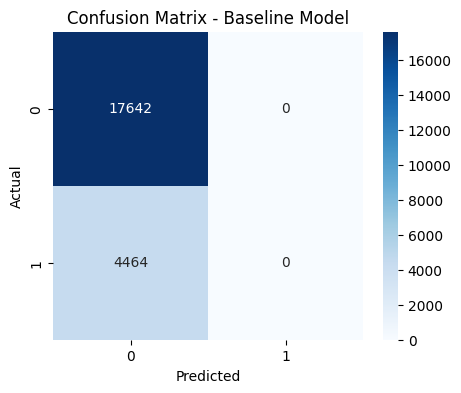

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [39]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

roc_auc = roc_auc_score(y_test, y_proba)
report_df.loc["ROC-AUC"] = [roc_auc, roc_auc, roc_auc, roc_auc]

display(report_df)

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

,precision,recall,f1-score,support
0,0.798064,1.000000,0.887692,17642.000000
1,0.000000,0.000000,0.000000,4464.000000
accuracy,0.798064,0.798064,0.798064,0.798064
macro avg,0.399032,0.500000,0.443846,22106.000000
weighted avg,0.636906,0.798064,0.708435,22106.000000
ROC-AUC,0.610208,0.610208,0.610208,0.610208


### Rezultati baseline modela (logistic regression)

U baseline varijanti korišćeni su isključivo originalni atributi iz skupa podataka, bez dodatnog feature engineering-a i bez balansiranja klasa. Iz modela su isključeni identifikatori i vremenski atributi u sirovom obliku, kako bi baseline predstavljao jednostavnu i referentnu početnu tačku za poređenje sa unapređenim varijantama modela.

Rezultati baseline modela ukazuju na ozbiljan problem u vezi sa neuravnoteženošću klasa.

Iako model postiže relativno visoku tačnost od približno 80%, analiza konfuzione matrice pokazuje da model praktično uopšte ne prepoznaje klasu No-show (klasa 1). Tačnije, svi primeri su klasifikovani kao klasa 0 (Show), čime model u potpunosti ignoriše manjinsku klasu.

Ovo se jasno vidi kroz sledeće metrike:
- precision za klasu No-show: 0.00  
- recall za klasu No-show: 0.00  
- F1-score za klasu No-show: 0.00  

To znači da model nema nikakvu sposobnost detekcije pacijenata koji se ne pojavljuju na zakazan termin.

ROC-AUC vrednost iznosi oko 0.61, što ukazuje na postojanje određenog signala u podacima, ali model nije u stanju da taj signal iskoristi za klasifikaciju manjinske klase.

Ovakvo ponašanje modela je tipično u situacijama sa izraženom neuravnoteženošću podataka, gde model minimizuje ukupnu grešku favorizujući većinsku klasu.

## 3.2 Random Forest


Pored logističke regresije, treniran je i Random Forest model kako bi se dobio nelinearni referentni model.

Za razliku od logističke regresije, Random Forest:
- ne zahteva skaliranje podataka
- može da modeluje nelinearne odnose između atributa
- robusniji je na šum u podacima

Ovaj model služi kao poređenje kako bi se procenilo da li kompleksniji modeli donose poboljšanje u odnosu na jednostavan linearni model.

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)
y_proba_rf = rf_baseline.predict_proba(X_test)[:, 1]

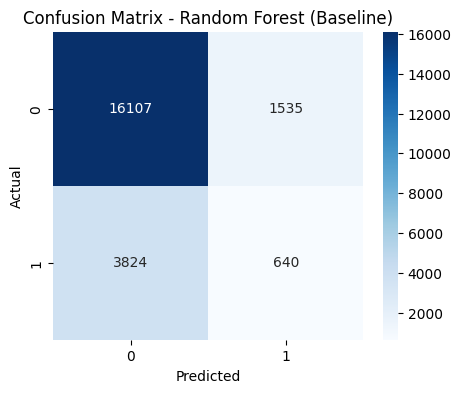

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_rf_df = pd.DataFrame(report_rf).transpose()

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
report_rf_df.loc["ROC-AUC"] = [roc_auc_rf, roc_auc_rf, roc_auc_rf, roc_auc_rf]

display(report_rf_df)

,precision,recall,f1-score,support
0,0.808138,0.912992,0.857371,17642.000000
1,0.294253,0.143369,0.192800,4464.000000
accuracy,0.757577,0.757577,0.757577,0.757577
macro avg,0.551195,0.528180,0.525086,22106.000000
weighted avg,0.704366,0.757577,0.723170,22106.000000
ROC-AUC,0.582013,0.582013,0.582013,0.582013


### Rezultati baseline Random Forest modela:
Oni ukazuju na nešto bolju ravnotežu u odnosu na logističku regresiju, ali i dalje prisutan problem sa neuravnoteženošću klasa.

Za razliku od logističke regresije, Random Forest uspeva da prepozna određeni broj instanci klase No-show (klasa 1), što se vidi kroz recall od približno 0.15. Međutim, ovaj rezultat je i dalje nizak, što znači da model propušta veliki broj pacijenata koji se neće pojaviti.

Preciznost za klasu No-show iznosi oko 0.30, što ukazuje da kada model predvidi ovu klasu, to nije naročito pouzdano. F1-score za manjinsku klasu je nizak (~0.20), što potvrđuje da performanse modela u ovom segmentu nisu zadovoljavajuće.

Ukupna tačnost modela ostaje relativno visoka (~0.76), ali je to posledica dominacije većinske klase. ROC-AUC vrednost (~0.59) pokazuje blagu sposobnost razdvajanja klasa, ali i dalje ukazuje na ograničenja modela bez dodatnih unapređenja.

Zaključno, iako Random Forest pokazuje određeno poboljšanje u odnosu na logističku regresiju, i dalje je jasno da bez balansiranja podataka i dodatnog feature engineering-a model ne može adekvatno da reši problem klasifikacije manjinske klase.

# 4. Varijante unapređenja

## 4.1 Početna ideja unapređenja

Rezultati baseline modela pokazali su da model gotovo u potpunosti favorizuje dominantnu klasu i veoma loše prepoznaje No-show slučajeve.

Zbog toga se unapređenje modela sprovodi postepeno, kroz više koraka:
1. balansiranje uticaja klasa,
2. uvođenje novih atributa na osnovu prethodne analize,
3. ponovno treniranje i poređenje rezultata.

Cilj ovakvog pristupa je da se jasno sagleda doprinos svake pojedinačne promene performansama modela.

## 4.2 Balansiranje klasa 

Balanced model uvodi balansiranje klasa korišćenjem parametra `class_weight='balanced'`.

Na ovaj način model daje veću važnost manjinskoj klasi (No-show),
što direktno utiče na povećanje recall-a za tu klasu.


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_proba_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print("Balanced model koristi iste feature-e kao baseline model.")
print("Broj feature-a:", X_train.shape[1])

Balanced model koristi iste feature-e kao baseline model.
Broj feature-a: 88


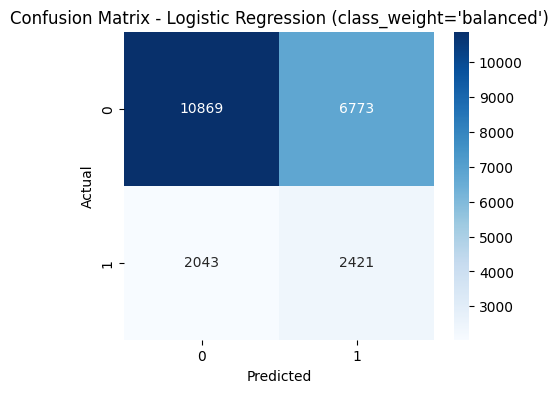

In [44]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(5,4))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (class_weight='balanced')")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
report_balanced = classification_report(y_test, y_pred_balanced, output_dict=True)
report_balanced_df = pd.DataFrame(report_balanced).transpose()

roc_auc_balanced = roc_auc_score(y_test, y_proba_balanced)
report_balanced_df.loc["ROC-AUC"] = [roc_auc_balanced, roc_auc_balanced, roc_auc_balanced, roc_auc_balanced]

display(report_balanced_df)

,precision,recall,f1-score,support
0,0.841775,0.616087,0.711462,17642.000000
1,0.263324,0.542339,0.354517,4464.000000
accuracy,0.601194,0.601194,0.601194,0.601194
macro avg,0.552549,0.579213,0.532990,22106.000000
weighted avg,0.724965,0.601194,0.639382,22106.000000
ROC-AUC,0.610032,0.610032,0.610032,0.610032


### Interpretacija rezultata balanced modela (Logistic Regression)

Uvođenjem parametra `class_weight="balanced"` postiže se značajna promena u ponašanju modela u odnosu na baseline varijantu.

Za razliku od baseline modela, koji je u potpunosti ignorisao klasu No-show, balanced model uspeva da prepozna značajan broj instanci ove klase. Recall za klasu No-show porastao je sa 0.00 na približno 0.54, što predstavlja veliko unapređenje u detekciji pacijenata koji se ne pojavljuju na zakazan termin.

Ovo se jasno vidi i u konfuzionoj matrici, gde model sada pravi realnu razliku između klasa i više ne favorizuje isključivo većinsku klasu.

Međutim, ovo poboljšanje dolazi uz određeni kompromis. Ukupna tačnost modela opada sa oko 80% na približno 60%, što je očekivano, jer model više ne favorizuje većinsku klasu već pokušava da uravnoteži performanse između obe klase.

Precision za klasu No-show iznosi oko 0.26, što ukazuje na povećan broj lažno pozitivnih predikcija, odnosno model češće pogrešno klasifikuje pacijente koji će doći kao No-show.

F1-score za klasu No-show značajno je poboljšan (sa 0.00 na oko 0.35), što potvrđuje da model sada ima realnu sposobnost detekcije ove klase.

ROC-AUC vrednost ostaje približno ista (~0.61), što ukazuje da balansiranje utiče pre svega na prag odlučivanja i raspodelu grešaka, a ne na samu separabilnost klasa.

**Krajnji zaključak:** Balansiranje klasa značajno poboljšava sposobnost modela da detektuje No-show slučajeve, ali uvodi kompromis u vidu smanjenja ukupne tačnosti i povećanja broja lažno pozitivnih predikcija.

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_pred_rf_bal = rf_balanced.predict(X_test)
y_proba_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

print("Balanced Random Forest koristi iste feature-e kao baseline model.")
print("Broj feature-a:", X_train.shape[1])

Balanced Random Forest koristi iste feature-e kao baseline model.
Broj feature-a: 88


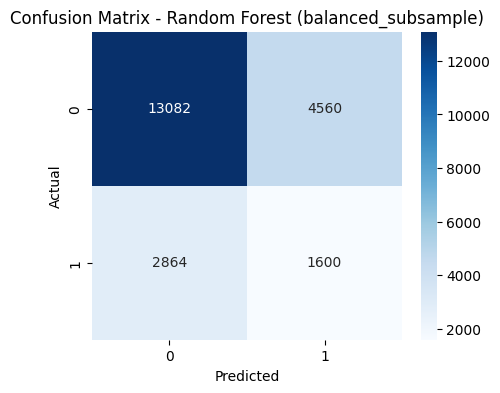

In [47]:
cm_rf_bal = confusion_matrix(y_test, y_pred_rf_bal)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_bal, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (balanced_subsample)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
report_rf_bal = classification_report(y_test, y_pred_rf_bal, output_dict=True)
report_rf_bal_df = pd.DataFrame(report_rf_bal).transpose()

roc_auc_rf_bal = roc_auc_score(y_test, y_proba_rf_bal)
report_rf_bal_df.loc["ROC-AUC"] = [roc_auc_rf_bal, roc_auc_rf_bal, roc_auc_rf_bal, roc_auc_rf_bal]

display(report_rf_bal_df)

,precision,recall,f1-score,support
0,0.820394,0.741526,0.778969,17642.000000
1,0.259740,0.358423,0.301205,4464.000000
accuracy,0.664164,0.664164,0.664164,0.664164
macro avg,0.540067,0.549974,0.540087,22106.000000
weighted avg,0.707178,0.664164,0.682491,22106.000000
ROC-AUC,0.576628,0.576628,0.576628,0.576628


### Interpretacija rezultata balanced Random Forest modela

Uvođenjem balansiranja klasa putem parametra `class_weight="balanced_subsample"` dolazi do značajne promene u ponašanju Random Forest modela u odnosu na baseline varijantu.

Model sada uspeva da prepozna znatno veći broj instanci klase No-show, što se vidi kroz recall od približno 0.37. Ovo predstavlja značajno poboljšanje u odnosu na baseline, gde je detekcija ove klase bila veoma ograničena.

U konfuzionoj matrici može se primetiti da model više ne ignoriše manjinsku klasu, već aktivno klasifikuje deo tih instanci kao No-show, čime se postiže realnija raspodela predikcija.

Preciznost za klasu No-show iznosi oko 0.27, što ukazuje na to da model i dalje pravi veći broj lažno pozitivnih predikcija. Drugim rečima, deo pacijenata koji se zapravo pojave na termin model pogrešno klasifikuje kao No-show.

F1-score za manjinsku klasu iznosi približno 0.31, što predstavlja značajno unapređenje u odnosu na baseline model i pokazuje da balansiranje ima pozitivan efekat na ukupnu sposobnost modela da detektuje ovu klasu.

Ukupna tačnost modela opada na oko 0.66, što je očekivano jer model više ne favorizuje većinsku klasu, već pokušava da uravnoteži performanse između klasa.

ROC-AUC vrednost (~0.58) pokazuje blagu sposobnost razdvajanja klasa, ali i dalje ukazuje na to da model ima ograničenja bez dodatnog unapređenja feature-a.

Krajnji zaključak: Balansiranje klasa značajno poboljšava sposobnost Random Forest modela da detektuje No-show slučajeve, ali uvodi kompromis u vidu smanjenja ukupne tačnosti i preciznosti, što je tipično ponašanje kod problema sa neuravnoteženim klasama.

## 4.3 Feature engineering i dodatno čišćenje

In [49]:
df_improved = df.copy()

# target
df_improved["NoShow_binary"] = df_improved["No-show"].map({"No": 0, "Yes": 1})


# dodatno čišćenje samo za improved model

df_improved = df_improved[df_improved["WaitingDays"] >= 0].copy()
df_improved = df_improved[df_improved["Age"] >= 0].copy()


# feature engineering

# grupisanje WaitingDays
df_improved["WaitingDaysGroup"] = pd.cut(
    df_improved["WaitingDays"],
    bins=[-1, 0, 3, 7, 14, 30, 1000],
    labels=["0", "1-3", "4-7", "8-14", "15-30", "30+"]
)

# grupisanje Age
df_improved["AgeGroup"] = pd.cut(
    df_improved["Age"],
    bins=[-1, 12, 18, 35, 60, 120],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

# interakcija SMS i dužine čekanja
df_improved["SMS_Waiting_interaction"] = (
    df_improved["SMS_received"] * df_improved["WaitingDays"]
)


# vikend termin
df_improved["IsWeekend"] = (
    df_improved["AppointmentDay"].dt.weekday >= 5
).astype(int)

# dugo čekanje
df_improved["IsLongWaiting"] = (
    df_improved["WaitingDays"] > 7
).astype(int)

df_improved["HasChronicDisease"] = (
    (df_improved["Hipertension"] == 1) |
    (df_improved["Diabetes"] == 1)
).astype(int)

df_improved = df_improved.drop(columns=["Hipertension", "Diabetes"])

# Handicap -> binarni atribut
df_improved["HasHandicap"] = (df_improved["Handcap"] > 0).astype(int)

# opciono: izbacujemo originalni atribut
df_improved = df_improved.drop(columns=["Handcap"])

print("Oblik improved skupa nakon čišćenja:", df_improved.shape)

Oblik improved skupa nakon čišćenja: (110521, 22)


## Feature engineering i dodatno čišćenje podataka

U drugom koraku unapređenja modela uvedeno je dodatno čišćenje podataka i kreirani su novi atributi na osnovu prethodne eksplorativne analize.

### Čišćenje podataka

Najpre su uklonjeni redovi sa nelogičnim vrednostima:
- `WaitingDays < 0`
- `Age < 0`

Ovaj korak nije primenjen u baseline modelu, već je ostavljen za improved varijantu kako bi se jasno sagledao uticaj poboljšanja kvaliteta podataka.

---

### Kreiranje novih atributa

Na osnovu uočenih obrazaca u podacima uvedeni su sledeći atributi:

- **`WaitingDaysGroup`**  
  Grupisanje vremena čekanja radi modelovanja nelinearnog odnosa između dužine čekanja i verovatnoće nedolaska.

- **`AgeGroup`**  
  Grupisanje pacijenata po starosnim kategorijama, jer različite starosne grupe pokazuju različite obrasce ponašanja.

- **`SMS_Waiting_interaction`**  
  Interakcioni atribut koji kombinuje SMS podsetnik i dužinu čekanja, jer je analiza pokazala da efekat SMS-a zavisi od WaitingDays.

- **`IsWeekend`**  
  Indikator da li je termin zakazan tokom vikenda.

- **`IsLongWaiting`**  
  Binarni atribut koji označava da li je vreme čekanja duže od 7 dana.

- **`HasChronicDisease`**  
  Indikator da li pacijent ima hronične bolesti (hipertenzija ili dijabetes).

- **`HasHandicap`**  
  Atribut *Handcap* je transformisan u binarni oblik zbog malog broja instanci u višim kategorijama:
  - 0 → nema hendikep  
  - 1 → ima hendikep  


### Uklanjanje redundantnih atributa

Atribut `HasChronicDisease` je izveden iz atributa `Hipertension` i `Diabetes`.

Problem: Zadržavanje svih ovih atributa uvodi multikolinearnost, jer sadrže istu informaciju.

Rešenje: Originalni atributi `Hipertension` i `Diabetes` su uklonjeni, a zadržan je samo agregirani atribut `HasChronicDisease`.

---

### Zaključak

Na ovaj način improved model dobija informativniju i kvalitetniju reprezentaciju podataka.

Uvođenjem novih atributa omogućeno je modelu da bolje uhvati složene odnose u podacima, što dovodi do poboljšanja performansi u odnosu na baseline model.

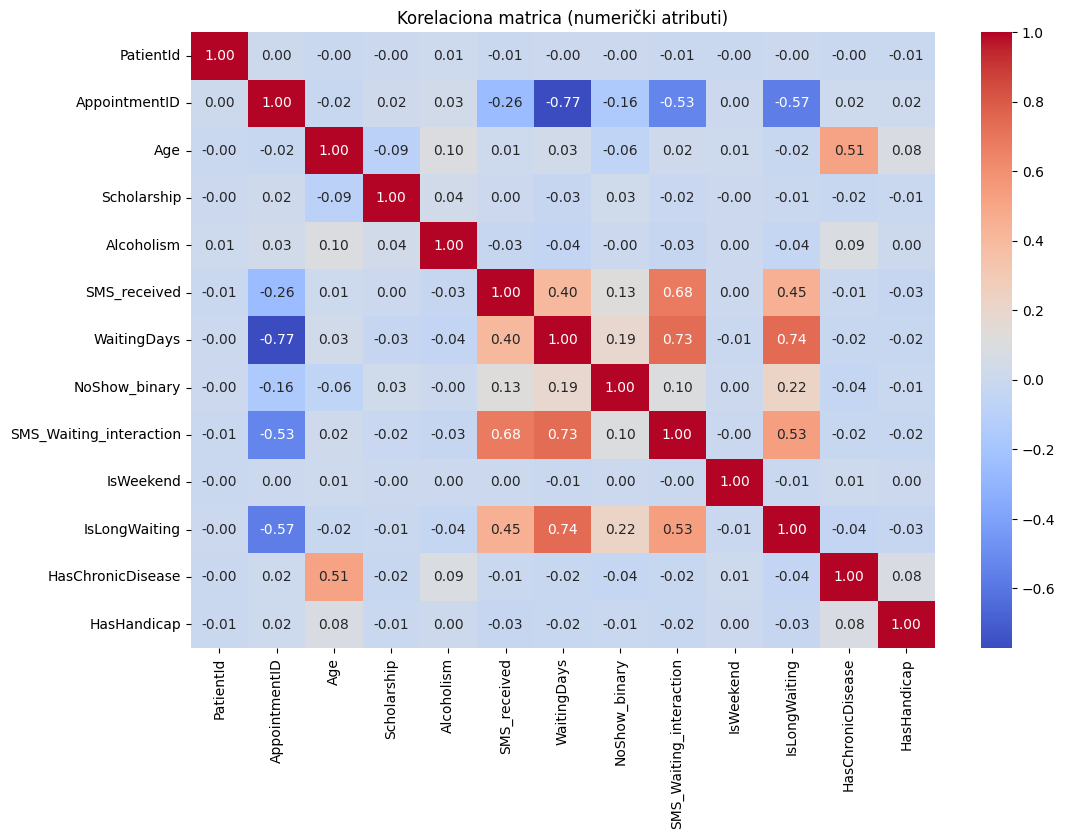

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# uzmi samo numeričke feature-e
numeric_features = df_improved.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_features.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelaciona matrica (numerički atributi)")
plt.show()

### Analiza multikolinearnosti

Analizom korelacione matrice uočeno je postojanje korelacije između pojedinih atributa, posebno između:

- `WaitingDays`, `IsLongWaiting` i `WaitingDaysGroup`,
- `Age` i `AgeGroup`.

Ovo je očekivano, s obzirom na to da su neki atributi izvedeni iz postojećih.

Uprkos tome, ovi atributi nisu uklonjeni iz modela jer:

- omogućavaju modelu različite reprezentacije iste informacije,
- mogu poboljšati performanse kod modela koji nisu osetljivi na multikolinearnost (npr. Random Forest),
- omogućavaju lakšu interpretaciju određenih obrazaca (npr. grupisanje po starosti ili dužini čekanja).

Kod logističke regresije, multikolinearnost može uticati na stabilnost koeficijenata, ali u ovom radu fokus je bio na performansama modela, a ne na interpretaciji pojedinačnih koeficijenata.

In [51]:
df_improved = df_improved.drop(columns=[
    "PatientId",
    "AppointmentID",
    "ScheduledDay",
    "AppointmentDay",
    "No-show"
], errors="ignore")

print("Feature-i koji ulaze u improved model:")
for col in df_improved.columns:
    print("-", col)

Feature-i koji ulaze u improved model:
- Gender
- Age
- Neighbourhood
- Scholarship
- Alcoholism
- SMS_received
- WaitingDays
- AppointmentDayOfWeek
- WaitingDaysGroup
- AgeGroup
- WaitingDays_group
- NoShow_binary
- SMS_Waiting_interaction
- IsWeekend
- IsLongWaiting
- HasChronicDisease
- HasHandicap


In [52]:
from sklearn.model_selection import train_test_split

X_imp = df_improved.drop("NoShow_binary", axis=1)
y_imp = df_improved["NoShow_binary"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

In [53]:
X_train_imp = pd.get_dummies(X_train_imp, drop_first=True)
X_test_imp = pd.get_dummies(X_test_imp, drop_first=True)

X_train_imp, X_test_imp = X_train_imp.align(X_test_imp, join="left", axis=1, fill_value=0)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler_imp = StandardScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

In [55]:
model_improved = LogisticRegression(max_iter=1000, class_weight="balanced")
model_improved.fit(X_train_imp_scaled, y_train_imp)

y_pred_improved = model_improved.predict(X_test_imp_scaled)
y_proba_improved = model_improved.predict_proba(X_test_imp_scaled)[:, 1]

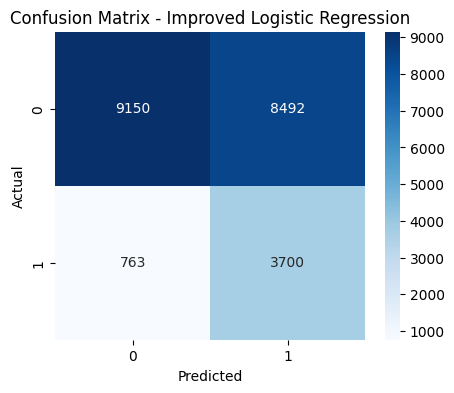

In [56]:
cm_improved = confusion_matrix(y_test_imp, y_pred_improved)

plt.figure(figsize=(5,4))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Improved Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [57]:
report_improved = classification_report(y_test_imp, y_pred_improved, output_dict=True)
report_improved_df = pd.DataFrame(report_improved).transpose()

roc_auc_improved = roc_auc_score(y_test_imp, y_proba_improved)
report_improved_df.loc["ROC-AUC"] = [roc_auc_improved, roc_auc_improved, roc_auc_improved, roc_auc_improved]

display(report_improved_df)

,precision,recall,f1-score,support
0,0.923030,0.518649,0.664126,17642.000000
1,0.303478,0.829039,0.444311,4463.000000
accuracy,0.581316,0.581316,0.581316,0.581316
macro avg,0.613254,0.673844,0.554219,22105.000000
weighted avg,0.797943,0.581316,0.619746,22105.000000
ROC-AUC,0.721719,0.721719,0.721719,0.721719


### Interpretacija rezultata improved modela: Logistic Regression

U unapređenoj varijanti modela uvedeni su novi atributi i dodatno čišćenje podataka sa ciljem poboljšanja detekcije No-show slučajeva.

U odnosu na prethodne modele, improved model pokazuje bolje razdvajanje klasa. Najvažnije unapređenje ogleda se u povećanju recall-a za klasu No-show (1) na približno 0.83, što znači da model uspešno prepoznaje veliki broj pacijenata koji se ne pojavljuju na zakazan termin.

Ovo predstavlja značajan napredak u odnosu na balanced model (gde je recall bio znatno niži), a naročito u odnosu na baseline model koji gotovo nije detektovao ovu klasu.

Takođe, ROC-AUC vrednost iznosi oko 0.72, što ukazuje na solidnu sposobnost modela da razlikuje dve klase i potvrđuje da uvedeni atributi doprinose kvalitetnijoj reprezentaciji podataka.

Međutim, ovo unapređenje dolazi uz izražen kompromis. Precision za klasu No-show iznosi oko 0.30, što znači da model pravi veći broj lažno pozitivnih predikcija — odnosno često predviđa da pacijent neće doći, iako će se zapravo pojaviti.

Takođe, ukupna tačnost modela iznosi oko 58%, što je niže u odnosu na jednostavnije modele. Ovo je posledica toga što model sada favorizuje detekciju manjinske klase (No-show), umesto optimizacije ukupne tačnosti.

Ukupno posmatrano, model je pomerio fokus sa opšte tačnosti ka uspešnijem prepoznavanju kritične klase No-show, što u kontekstu ovog problema ima veću praktičnu vrednost.


In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_improved = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",
    random_state=42
)

rf_improved.fit(X_train_imp, y_train_imp)

y_pred_rf_improved = rf_improved.predict(X_test_imp)
y_proba_rf_improved = rf_improved.predict_proba(X_test_imp)[:, 1]

print("Improved Random Forest koristi unapređeni skup atributa.")
print("Broj feature-a:", X_train_imp.shape[1])

Improved Random Forest koristi unapređeni skup atributa.
Broj feature-a: 110


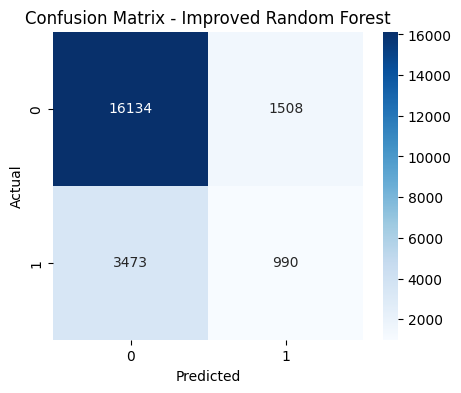

In [59]:
cm_rf_improved = confusion_matrix(y_test_imp, y_pred_rf_improved)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_improved, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Improved Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
report_rf_improved = classification_report(y_test_imp, y_pred_rf_improved, output_dict=True)
report_rf_improved_df = pd.DataFrame(report_rf_improved).transpose()

roc_auc_rf_improved = roc_auc_score(y_test_imp, y_proba_rf_improved)
report_rf_improved_df.loc["ROC-AUC"] = [
    roc_auc_rf_improved,
    roc_auc_rf_improved,
    roc_auc_rf_improved,
    roc_auc_rf_improved
]

display(report_rf_improved_df)

,precision,recall,f1-score,support
0,0.822869,0.914522,0.866278,17642.000000
1,0.396317,0.221824,0.284442,4463.000000
accuracy,0.774666,0.774666,0.774666,0.774666
macro avg,0.609593,0.568173,0.575360,22105.000000
weighted avg,0.736748,0.774666,0.748806,22105.000000
ROC-AUC,0.716314,0.716314,0.716314,0.716314


### Interpretacija rezultata improved Random Forest modela

Rezultati improved Random Forest modela pokazuju efekat kombinacije unapređenja podataka i balansiranja klasa.

Model ostvaruje ukupnu tačnost od približno 0.77, što predstavlja značajno poboljšanje u odnosu na logističku regresiju i ukazuje na stabilnije ukupne performanse.

Kada je u pitanju klasa No-show (1), model postiže recall od približno 0.22 i precision od približno 0.39. Ovo znači da model prepoznaje relativno mali deo stvarnih No-show slučajeva, ali kada ih predvidi, ta predikcija je češće tačna nego kod logističke regresije.

Drugim rečima, Random Forest je konzervativniji model: ređe predviđa No-show, ali kada to uradi, veća je verovatnoća da je predikcija tačna.

F1-score za No-show klasu iznosi oko 0.28, što ukazuje na ograničenu balansiranost između precision-a i recall-a.

ROC-AUC vrednost iznosi približno 0.72, što potvrđuje da model ima dobru sposobnost razdvajanja klasa, iako ne uspeva da efikasno detektuje manjinsku klasu.

Ključni kompromis: 

U poređenju sa logističkom regresijom, Random Forest postiže veću preciznost za No-show klasu, ali uz značajno niži recall. To znači da model pravi manje lažno pozitivnih predikcija, ali propušta veći broj stvarnih No-show slučajeva.

Zaključak:

Improved Random Forest model daje stabilnije i preciznije predikcije, ali nije dovoljno osetljiv na manjinsku klasu No-show.

U kontekstu ovog problema, gde je cilj identifikacija pacijenata koji se neće pojaviti na zakazan termin, model sa većim recall-om može imati veću praktičnu vrednost, iako ima nižu ukupnu tačnost.

---

In [61]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.30, 0.80, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_proba_improved >= t).astype(int)

    precision = precision_score(y_test_imp, y_pred_t, zero_division=0)
    recall = recall_score(y_test_imp, y_pred_t, zero_division=0)
    f1 = f1_score(y_test_imp, y_pred_t, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
display(threshold_df)

,threshold,precision,recall,f1
0,0.30,0.283251,0.920009,0.433145
1,0.35,0.283855,0.918665,0.433702
2,0.40,0.285123,0.910822,0.434295
3,0.45,0.292037,0.884159,0.439054
4,0.50,0.303478,0.829039,0.444311
5,0.55,0.317734,0.722608,0.441388
6,0.60,0.334394,0.564867,0.420097
7,0.65,0.361791,0.387408,0.374161
8,0.70,0.393030,0.199641,0.264785
9,0.75,0.408300,0.068340,0.117083


In [62]:
best_t = threshold_df.sort_values(by="f1", ascending=False).iloc[0]["threshold"]
print("Najbolji threshold:", best_t)

Najbolji threshold: 0.49999999999999994


Izvršeno je podešavanje decision threshold-a, pri čemu je utvrđeno da optimalna vrednost (~0.5) ne donosi značajno poboljšanje performansi u odnosu na podrazumevani prag.

Napomena: improved modeli trenirani su nad dodatno očišćenim skupom podataka, zbog čega broj instanci blago odstupa u odnosu na baseline i balanced varijante.

# 5. Finalno poređenje i zaključak

U nastavku je prikazano poređenje svih modela:

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

def add_result(name, y_true, y_pred, y_proba):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    })

# BASELINE
add_result("Baseline LR", y_test, y_pred, y_proba)
add_result("Baseline RF", y_test, y_pred_rf, y_proba_rf)

# BALANCED
add_result("Balanced LR", y_test, y_pred_balanced, y_proba_balanced)
add_result("Balanced RF", y_test, y_pred_rf_bal, y_proba_rf_bal)

# IMPROVED
add_result("Improved LR", y_test_imp, y_pred_improved, y_proba_improved)
add_result("Improved RF", y_test_imp, y_pred_rf_improved, y_proba_rf_improved)

# tabela
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

def highlight_best(col):
    max_val = col.max()
    return [
        "background-color: #c6efce; color: #006100; font-weight: bold;"
        if v == max_val else ""
        for v in col
    ]

styled_results = (
    results_df.style
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
    .apply(highlight_best, subset=metric_cols)
    .set_properties(**{
        "text-align": "center",
        "font-size": "14px",
        "padding": "8px",
        "border": "1px solid #d0d0d0"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("border", "1px solid #d0d0d0"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("border-collapse", "collapse")
            ]
        }
    ])
)

display(styled_results)

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Improved LR,0.581,0.303,0.829,0.444,0.722
1,Balanced LR,0.601,0.263,0.542,0.355,0.610
2,Balanced RF,0.664,0.260,0.358,0.301,0.577
3,Improved RF,0.775,0.396,0.222,0.284,0.716
4,Baseline RF,0.758,0.294,0.143,0.193,0.582
5,Baseline LR,0.798,0.000,0.000,0.000,0.610


## Analiza i poređenje modela

Rezultati jasno pokazuju razliku između baseline pristupa, balansiranja klasa i unapređenih modela sa dodatnim feature engineering-om.

### Ograničenja baseline modela

Baseline modeli, i logistička regresija i Random Forest, postižu relativno visoku vrednost **accuracy** metrike. Međutim, detaljnija analiza pokazuje da je ova metrika u ovom slučaju varljiva zbog izražene nebalansiranosti klasa.

Posebno je problematičan **Baseline Logistic Regression**, koji ima **recall = 0.00**. To znači da model uopšte ne prepoznaje *No-show* slučajeve, već praktično sve instance klasifikuje kao većinsku klasu (*Show*). Ovakvo ponašanje jasno ukazuje da model nije upotrebljiv u realnom scenariju, uprkos visokoj tačnosti (**accuracy ≈ 0.80**).

**Baseline Random Forest** pokazuje nešto bolje rezultate (**recall ≈ 0.14, F1 ≈ 0.19**), ali i dalje ima veoma ograničenu sposobnost detekcije manjinske klase.

---

### Uticaj balansiranja klasa

Uvođenjem balansiranja dolazi do značajnog pomaka u ponašanju modela.

Kod **Balanced Logistic Regression** dolazi do značajnog povećanja **recall** vrednosti (**≈ 0.54**), što znači da model uspeva da prepozna veći broj *No-show* slučajeva. Međutim, ovo poboljšanje dolazi uz pad **precision** (**≈ 0.26**) i **accuracy** (**≈ 0.60**), što je očekivano jer model postaje skloniji predikciji manjinske klase.

Kod **Balanced Random Forest** modela **recall ≈ 0.36**, uz **F1 ≈ 0.30**, što predstavlja poboljšanje u odnosu na baseline, ali i dalje slabije rezultate u poređenju sa logističkom regresijom.

Ovi rezultati potvrđuju da balansiranje ima ključnu ulogu kada je cilj detekcija manjinske klase, ali da samo po sebi nije dovoljno za optimalne performanse.

---

### Uticaj feature engineering-a i unapređenja modela

Najbolje rezultate postiže **Improved Logistic Regression** model, koji ima:

- **recall ≈ 0.83**  
- **F1 ≈ 0.44**  
- **ROC-AUC ≈ 0.72**

Ovo ukazuje na to da model postiže najbolji balans između precision i recall i najuspešnije detektuje *No-show* slučajeve.

**Improved Random Forest** model ostvaruje:

- **accuracy ≈ 0.78**  
- **precision ≈ 0.40**  
- **recall ≈ 0.22**  
- **F1 ≈ 0.28**

Ovi rezultati pokazuju da Random Forest daje preciznije, ali konzervativnije predikcije — ređe detektuje *No-show* slučajeve, ali kada to uradi, veća je verovatnoća da je predikcija tačna.

Za razliku od logističke regresije, unapređenja kod Random Forest modela ne dovode do značajnog poboljšanja recall metrike, što ukazuje da dodatni feature-i nisu jednako korisni za oba algoritma.

---

### Ključni uvidi

- **Accuracy** nije adekvatna metrika za ovaj problem zbog nebalansiranih klasa  
- **Recall i F1-score** su ključne metrike jer direktno mere uspešnost detekcije *No-show* slučajeva  
- Balansiranje značajno poboljšava recall, ali smanjuje precision  
- Feature engineering ima presudan uticaj na performanse modela, posebno kod logističke regresije  

---

### Zaključak

Na osnovu svih rezultata može se zaključiti da je **Improved Logistic Regression** najpogodniji model za ovaj problem.

Ovaj model:

- postiže najbolji balans između precision i recall  
- značajno poboljšava detekciju *No-show* slučajeva  
- ostvaruje najviši **F1-score** i **ROC-AUC**  

Zaključno, rezultati jasno potvrđuju da kvalitet podataka, adekvatna obrada i pažljivo osmišljeni atributi imaju veći uticaj na performanse modela nego sam izbor algoritma.